# Cornerstone fine-tune — end-to-end pipeline test

Walks the whole `cornerstone_finetune` pipeline and **checks properties at every stage**:

| section | stage | what is checked |
|---|---|---|
| 1 | `prepare_data.py` (artifacts) | prepared cohort is RAS, 1 mm isotropic, liver-cropped; labels valid; meta consistent |
| 2 | `labels.py` | channel presets, partition counts, per-subject availability masks |
| 3 | `datamodule.py` | cohort/split determinism, crop ratios, prevalence, batch contents, channel overlaps |
| 4 | `losses.py` | Dice/Tversky/BCE/clDice property tests + channel masking |
| 5 | `module.py` | pretrained transfer (157/159), head bias prior, forward + sliding-window inference, checkpoint reload |
| 6 | `train.py --smoke` | real end-to-end fit (2 epochs), checkpoints + TensorBoard metrics appear |
| 7 | `predict.py` + scoring | real checkpoint over the test split, masks restored to the source grid, Dice vs ground truth, visual overlay |
| 8 | inference visualizations | 2D slices and 3D surfaces: predictions vs ground truth |
| 9 | class colours & Couinaud segments | one colour per detected class (2D/3D) + the 8 Couinaud segments overlaid (2D/3D) |
| 10 | verdict | summary of every check |

Each check is recorded by `check(name, ok, note)`; section 8 prints the full table.


In [14]:
from __future__ import annotations

import contextlib
import io
import json
import math
import os
import shutil
import subprocess
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
from IPython.display import display

%matplotlib inline

plt.rcParams.update({"figure.dpi": 100, "axes.grid": True, "grid.alpha": 0.3, "font.size": 10})

REPO = Path(".").resolve()
if not (REPO / "cornerstone_finetune").exists():
    raise RuntimeError("run this notebook from the repo root")

sys.path.insert(0, str(REPO / "cornerstone_finetune"))

PY = sys.executable
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print("repo:", REPO)
print("python:", PY)
print("device:", DEVICE, torch.cuda.get_device_name(0) if DEVICE == "cuda" else "")

# ---------------------------------------------------------------- check recorder
CHECKS = []

def check(name: str, ok: bool, note: str = ""):
    CHECKS.append({"section": _SECTION, "name": name, "ok": bool(ok), "note": str(note)})
    print(("PASS" if ok else "FAIL") + f"  {name}" + (f"  -- {note}" if note else ""))

_SECTION = "?"
def section(name: str):
    global _SECTION
    _SECTION = name
    print(f"\n{'=' * 70}\n{name}\n{'=' * 70}")

repo: /home/lois/tfm
python: /home/lois/.virtualenvs/torch/bin/python
device: cuda NVIDIA GeForce RTX 5090


In [15]:
section("1. prepare_data.py artifacts — data/cornerstone_prepared")

from labels import LABEL_IDS, NUM_LABELS, ID_TO_NAME

PREPARED = REPO / "data" / "cornerstone_prepared"
MASKS = REPO / "data" / "cornerstone_masks"

import nibabel as nib
from nibabel.orientations import aff2axcodes

manifest = json.loads((PREPARED / "manifest.json").read_text())
cases = manifest["cases"]
check("manifest exists with 38 cases", len(cases) == 38, f"n={len(cases)}; failed={manifest.get('failed')}")
check("manifest spacing is 1 mm isotropic", manifest["spacing"] == [1.0, 1.0, 1.0], str(manifest["spacing"]))
check("margin 32 mm", manifest["margin_mm"] == 32.0)

# labels.json must agree with labels.py (they are the pipeline's contract)
json_ids = json.loads((MASKS / "labels.json").read_text())
check("labels.json == LABEL_IDS", json_ids == LABEL_IDS)

n_bad_shape = n_bad_orient = n_bad_spacing = n_bad_ids = n_bad_counts = 0
dtypes = set()
for m in cases:
    case = m["case"]
    img = nib.load(str(PREPARED / case / "image.nii.gz"))
    lab = nib.load(str(PREPARED / case / "label.nii.gz"))
    if img.shape != lab.shape or tuple(img.shape) != tuple(m["shape"]):
        n_bad_shape += 1
    if img.affine.shape != (4, 4) or not np.allclose(img.affine, lab.affine, atol=1e-4):
        n_bad_shape += 1
    codes = aff2axcodes(img.affine)
    if codes != ("R", "A", "S"):
        n_bad_orient += 1
    sp = np.sqrt((img.affine[:3, :3] ** 2).sum(0))
    if not ((sp > 0.985) & (sp < 1.015)).all():
        n_bad_spacing += 1
    dtypes.add(img.header.get_data_dtype().name)
    # full-array checks
    L = np.asarray(lab.dataobj)
    ids = np.unique(L)
    if ids.size and (ids.min() < 0 or ids.max() > NUM_LABELS):
        n_bad_ids += 1
    counts = np.bincount(L.reshape(-1), minlength=NUM_LABELS + 1)
    got = {ID_TO_NAME[i]: int(counts[i]) for i in range(1, NUM_LABELS + 1)}
    if got != m["label_counts"]:
        n_bad_counts += 1
    if got["classLiver"] == 0:
        n_bad_counts += 1

check("image/label shapes agree with meta (all cases)", n_bad_shape == 0, f"bad={n_bad_shape}")
check("every crop reoriented to RAS", n_bad_orient == 0, f"bad={n_bad_orient}")
check("every crop at 1 mm isotropic spacing", n_bad_spacing == 0, f"bad={n_bad_spacing}")
check("labels within [0,15]", n_bad_ids == 0, f"bad={n_bad_ids}")
check("label_counts in meta match the arrays, liver non-empty", n_bad_counts == 0, f"bad={n_bad_counts}")
check("prepared image stored as int16", dtypes <= {"int16"}, str(dtypes))

# world-geometry consistency: the prepared 1 mm crop must span the same
# physical extent as the source-resolution crop (hi-lo voxels * source spacing)
def geo_ok(m):
    lo, hi = np.asarray(m["ras_crop_origin"]), np.asarray(m["ras_crop_end"])
    extent_mm = (hi - lo) * np.asarray(m["source_spacing"])
    return np.allclose(np.asarray(m["shape"]) * 1.0, extent_mm, rtol=0.02, atol=1.0)
n_geo = sum(not geo_ok(m) for m in cases)
check("prepared shape * 1 mm == source crop extent (all cases)", n_geo == 0, f"bad={n_geo}")

# crop is actually a crop: prepared voxel count << source voxel count
frac = [m["n_voxels"] / np.prod(m["source_shape"]) for m in cases]
check("crop is a small fraction of the source volume", max(frac) < 0.35, f"max={max(frac):.3f}")
print(f"prepared cohort: {len(cases)} cases, crop size {cases[0]['shape']}, "
      f"~{np.median([m['n_voxels'] for m in cases]) / 1e6:.1f} Mvox median")


1. prepare_data.py artifacts — data/cornerstone_prepared
PASS  manifest exists with 38 cases  -- n=38; failed=[]
PASS  manifest spacing is 1 mm isotropic  -- [1.0, 1.0, 1.0]
PASS  margin 32 mm
PASS  labels.json == LABEL_IDS


PASS  image/label shapes agree with meta (all cases)  -- bad=0
PASS  every crop reoriented to RAS  -- bad=0
PASS  every crop at 1 mm isotropic spacing  -- bad=0
PASS  labels within [0,15]  -- bad=0
PASS  label_counts in meta match the arrays, liver non-empty  -- bad=0
PASS  prepared image stored as int16  -- {'int16'}
PASS  prepared shape * 1 mm == source crop extent (all cases)  -- bad=0
PASS  crop is a small fraction of the source volume  -- max=0.257
prepared cohort: 38 cases, crop size [267, 213, 222], ~20.1 Mvox median


In [16]:
section("2. labels.py — presets, counts, availability")

from labels import (CHANNEL_PRESETS, CORE5, CORE6, CORE7, get_channels,
                    channel_counts, channel_availability, channel_names)

ok_sources = all(1 <= s <= NUM_LABELS for ch in CHANNEL_PRESETS["all15"] for s in ch.sources)
check("all15 covers every label id exactly once as sources",
      ok_sources and sorted(s for ch in CHANNEL_PRESETS["all15"] for s in ch.sources) == list(range(1, 16)))

ok_unique = all(len(n) == len(set(n)) for p in CHANNEL_PRESETS for n in [channel_names(CHANNEL_PRESETS[p])])
check("channel names unique within every preset", ok_unique)

check("core5 = core6 minus gallbladder", channel_names(CORE5) == [n for n in channel_names(CORE6) if n != "gallbladder"])

# partition property: union counts are exact sums of source counts
manifest = json.loads((PREPARED / "manifest.json").read_text())
for chs, tag in [(CORE6, "core6"), (CORE7, "core7")]:
    ok = True
    for m in manifest["cases"]:
        counts = {LABEL_IDS[n]: v for n, v in m["label_counts"].items()}
        L = np.asarray(nib.load(str(PREPARED / m["case"] / "label.nii.gz")).dataobj)
        for i, ch in enumerate(chs):
            union = np.zeros(L.shape, bool)
            for s in ch.sources:
                union |= L == s
            if int(union.sum()) != channel_counts(counts, chs)[i]:
                ok = False
                break
    check(f"{tag}: channel union voxel counts are exact (partition)", ok)

# core7 availability: hepatic_veins only annotated in ~25/38 subjects
no_hep = next(m for m in manifest["cases"] if m["label_counts"]["classVenaHepaticaDerecha"] == 0
              and m["label_counts"]["classVenaHepaticaMedia"] == 0
              and m["label_counts"]["classVenaHepaticaIzquierda"] == 0)
has_hep = next(m for m in manifest["cases"] if m["label_counts"]["classVenaHepaticaMedia"] > 0)
def avail_of(m, chs):
    counts = {LABEL_IDS[n]: v for n, v in m["label_counts"].items()}
    return channel_availability(counts, chs)
a_no, a_yes = avail_of(no_hep, CORE7), avail_of(has_hep, CORE7)
i = channel_names(CORE7).index("hepatic_veins")
check("core7 masks hepatic_veins where unannotated",
      a_no[i] == 0 and a_yes[i] == 1,
      f"no_hep={no_hep['case']} mask={a_no[i]}; has_hep={has_hep['case']} mask={a_yes[i]}")
check("core6 availability is all-1 everywhere", all(v == 1 for m in manifest["cases"] for v in avail_of(m, CORE6)))


2. labels.py — presets, counts, availability
PASS  all15 covers every label id exactly once as sources
PASS  channel names unique within every preset
PASS  core5 = core6 minus gallbladder
PASS  core6: channel union voxel counts are exact (partition)
PASS  core7: channel union voxel counts are exact (partition)
PASS  core7 masks hepatic_veins where unannotated  -- no_hep=RMV2025_0005_CT_UTV_VEP_L mask=0; has_hep=RMV2025_0001_CT_NCT_HBP_X mask=1
PASS  core6 availability is all-1 everywhere



3. datamodule.py — cohort, splits, transforms


<>:82: SyntaxWarning: invalid escape sequence '\c'
<>:82: SyntaxWarning: invalid escape sequence '\c'
/tmp/ipykernel_456300/512516849.py:82: SyntaxWarning: invalid escape sequence '\c'
  check("portal_tree\classVenaPorta (the pedicle part) subset of vessels",


PASS  37 usable records after MR exclusion  -- n=37
PASS  MR case excluded
PASS  skip reason recorded  -- ('RMV2025_0002_MR_NCT_ARP_N', 'modality MR')
PASS  split sizes 26/6/5  -- got 26/6/5
PASS  splits are disjoint and cover the cohort
PASS  split reproducible with seed 42
PASS  split matches the saved split.json of the core5_paper_cldice run
PASS  crop ratios sum to 1  -- [0.05, 0.143, 0.222, 0.222, 0.143, 0.222]
PASS  thin channels get ~70% of foreground crop centres  -- bg=0.050, thin share=0.700
PASS  class_prevalence matches the saved hparams  -- liver=0.08209 portal_tree=0.00123 ivc=0.00289 aorta=0.00648 vessels=0.00156
crop ratios (bg + per channel): [0.05, 0.143, 0.222, 0.222, 0.143, 0.222]


Loading dataset: 100%|██████████| 6/6 [00:05<00:00,  1.20it/s]


PASS  train batch: 4 patches of 96^3 x 1 channel  -- (4, 1, 96, 96, 96)
PASS  train batch: target has 5 sigmoid channels  -- (4, 5, 96, 96, 96)
PASS  train batch: intensities in [0,1] before unclipped augmentations (small overshoot ok)  -- [-0.01, 1.04]
PASS  train batch: targets are binary
PASS  train batch: channel_mask collated per patch, all-1 for core5  -- (4, 5)
PASS  vessels subset of liver (val case)
PASS  portal_tree\classVenaPorta (the pedicle part) subset of vessels


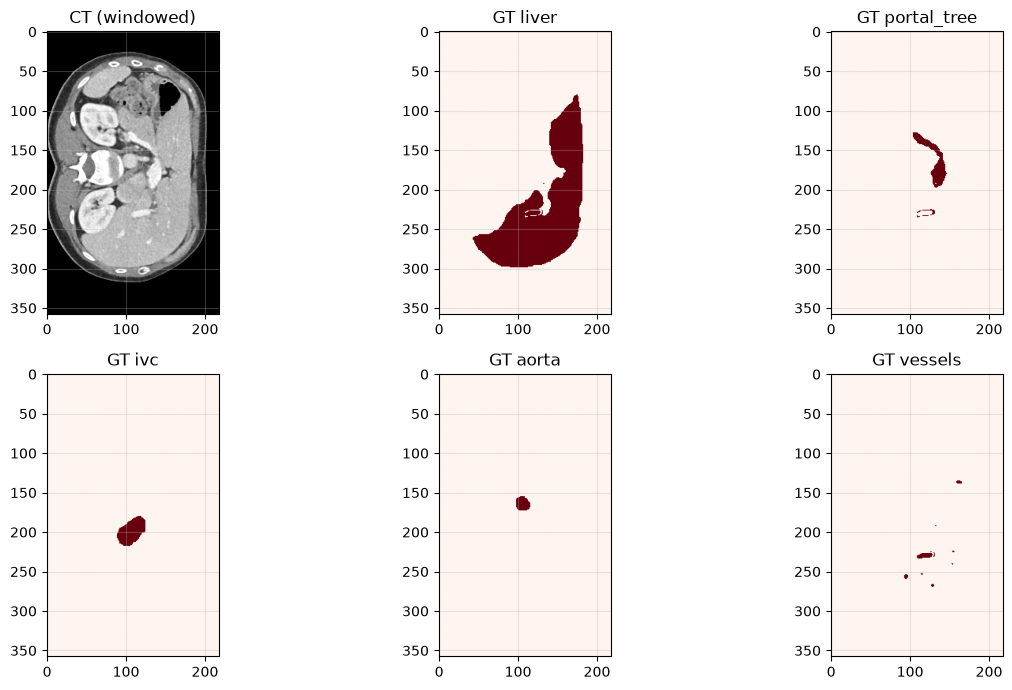

In [17]:
section("3. datamodule.py — cohort, splits, transforms")

from datamodule import CornerstoneDataModule, BuildChannelsd, SampleMapd
from labels import get_channels, channel_names
from monai.data import list_data_collate
import yaml

dm = CornerstoneDataModule(prepared_root=str(PREPARED), channel_preset="core5",
                           exclude_modality=["MR"])
records = dm.records()
check("37 usable records after MR exclusion", len(records) == 37, f"n={len(records)}")
mr = [r for r in records if "MR" in r["case"]]
check("MR case excluded", len(mr) == 0)
skipped = getattr(dm, "_skipped", [])
check("skip reason recorded", any("modality MR" in w for _, w in skipped), str(skipped[0] if skipped else ""))

train, val, test = dm.splits()
check("split sizes 26/6/5", (len(train), len(val), len(test)) == (26, 6, 5),
      f"got {len(train)}/{len(val)}/{len(test)}")
check("splits are disjoint and cover the cohort",
      len({r['case'] for r in train + val + test}) == 37)

# determinism + agreement with the real run's split.json
dm2 = CornerstoneDataModule(prepared_root=str(PREPARED), channel_preset="core5",
                            exclude_modality=["MR"])
tr2, va2, te2 = dm2.splits()
same = ([r["case"] for r in train] == [r["case"] for r in tr2]
        and [r["case"] for r in val] == [r["case"] for r in va2]
        and [r["case"] for r in test] == [r["case"] for r in te2])
check("split reproducible with seed 42", same)
saved = json.loads((REPO / "runs/cornerstone/core5_paper_cldice/split.json").read_text())
check("split matches the saved split.json of the core5_paper_cldice run",
      saved["train"] == [r["case"] for r in train] and saved["test"] == [r["case"] for r in test])

ratios = dm.sampling_ratios()
check("crop ratios sum to 1", abs(sum(ratios) - 1) < 1e-9, str([round(r, 3) for r in ratios]))
channels = get_channels("core5")
thin = [c.name for c in channels if c.thin]
bulk = [c.name for c in channels if not c.thin]
thin_share = sum(ratios[1 + channel_names(channels).index(n)] for n in thin)
check("thin channels get ~70% of foreground crop centres",
      abs(thin_share / (1 - ratios[0]) - 0.7) < 1e-9,
      f"bg={ratios[0]:.3f}, thin share={thin_share / (1 - ratios[0]):.3f}")

# prevalence must reproduce the run's hparams exactly
prev = dm.class_prevalence()
hp = yaml.safe_load((REPO / "runs/cornerstone/core5_paper_cldice/tb/version_0/hparams.yaml").read_text())
check("class_prevalence matches the saved hparams",
      np.allclose(prev, hp["prevalence"], rtol=1e-6, atol=1e-9),
      " ".join(f"{n}={p:.5f}" for n, p in zip(dm.channel_names, prev)))
print("crop ratios (bg + per channel):", [round(r, 3) for r in ratios])

# one real training batch through the whole transform chain. The train
# transform returns ``samples_per_volume`` crops as a list; the DataLoader
# collates them with ``list_data_collate``, and so do we here.
dm.setup("fit")
batch = list_data_collate(dm.train_ds[0])
img, lab = np.asarray(batch["image"]), np.asarray(batch["label"])
mask = np.asarray(batch["channel_mask"])
check("train batch: 4 patches of 96^3 x 1 channel", img.shape == (4, 1, 96, 96, 96), str(img.shape))
check("train batch: target has 5 sigmoid channels", lab.shape == (4, 5, 96, 96, 96), str(lab.shape))
check("train batch: intensities in [0,1] before unclipped augmentations (small overshoot ok)",
      img.min() >= -0.2 and img.max() <= 1.2,
      f"[{img.min():.2f}, {img.max():.2f}]")
check("train batch: targets are binary", set(np.unique(lab)) <= {0.0, 1.0})
check("train batch: channel_mask collated per patch, all-1 for core5",
      mask.shape == (4, 5) and (mask == 1).all(), str(mask.shape))

# channel-overlap invariants on a whole val case. portal_tree =
# classVenaPorta (id 2, partly extrahepatic) + pedicles, so only its pedicle
# part must sit inside the intrahepatic vessel union.
rec = dm.val_ds[0]
vimg, vlab = np.asarray(rec["image"]), np.asarray(rec["label"])
liver, portal, vessels = vlab[0], vlab[1], vlab[4]
check("vessels subset of liver (val case)", bool(((vessels == 1) <= (liver == 1)).all()))
# BuildChannelsd builds portal_tree from [2]+PEDICLES and vessels from
# INTRAHEPATIC (no id 2): construct the pedicle-only target and verify it lies
# inside vessels
ped = np.zeros(portal.shape, bool)
for s in [12, 13, 14, 15]:
    ped |= np.asarray(nib.load(str(PREPARED / rec["case"] / "label.nii.gz")).dataobj) == s
check("portal_tree\classVenaPorta (the pedicle part) subset of vessels",
      bool(((ped == 1) <= (vessels == 1)).all()))

# visual: one val case, mid slices
z = int(np.argmax(portal.sum(axis=(0, 1))))
fig, axes = plt.subplots(2, 3, figsize=(13, 7))
axes[0, 0].imshow(vimg[0, :, :, z], cmap="gray"); axes[0, 0].set_title("CT (windowed)")
for ax, (c, name) in zip(axes.ravel()[1:], enumerate(dm.channel_names)):
    ax.imshow(vlab[c, :, :, z], cmap="Reds", vmin=0, vmax=1); ax.set_title(f"GT {name}")
fig.tight_layout(); plt.show()

In [18]:
section("4. losses.py — property tests")

from losses import (DiceBCELoss, SoftClDiceLoss, MultiLabelLoss, masked_dice_loss,
                    masked_tversky_loss, _broadcast_mask)

torch.manual_seed(0)
B, C = 2, 3

# --- Dice: identical -> 0 ; all-background vs fg -> ~1 -----------------------
t = (torch.rand(B, C, 8, 8, 8) > 0.9).float()
check("masked dice(probs==target) == 0",
      masked_dice_loss(t, t, torch.ones(B, C)).item() < 1e-6,
      f"{masked_dice_loss(t, t, torch.ones(B, C)).item():.2e}")
dense = torch.ones(B, C, 8, 8, 8)
check("masked dice(all-background vs dense fg target) == 1 (up to smooth)",
      abs(masked_dice_loss(torch.zeros_like(dense), dense, torch.ones(B, C)).item() - 1) < 5e-3,
      f"{masked_dice_loss(torch.zeros_like(dense), dense, torch.ones(B, C)).item():.4f}")

# --- channel masking: a masked-out channel contributes nothing ----------------
loss_full = masked_dice_loss(t, t * 0.0, torch.ones(B, C))
mask = torch.ones(B, C); mask[:, 1] = 0.0
loss_masked = masked_dice_loss(t, t * 0.0, mask)
mask_kept = torch.ones(B, C - 1)
loss_manual = masked_dice_loss(t[:, [0, 2]], t[:, [0, 2]] * 0.0, mask_kept)
check("channel mask excludes a channel from the loss",
      abs(loss_masked.item() - loss_manual.item()) < 1e-6,
      f"{loss_masked.item():.4f} vs {loss_manual.item():.4f}")

# --- broadcast: one mask per subject -> one per patch -------------------------
m_subj = torch.tensor([[1.0, 1.0, 0.0], [1.0, 0.0, 1.0]])   # 2 subjects, 3 ch
mb = _broadcast_mask(m_subj, torch.zeros(6, 3))              # 3 patches per subject
check("subject-level masks repeated per patch",
      mb.shape == (6, 3) and torch.equal(mb, m_subj.repeat_interleave(3, 0)))
check("no mask -> all ones", torch.equal(_broadcast_mask(None, torch.zeros(2, 3)), torch.ones(2, 3)))

# --- Tversky asymmetry: beta > alpha must penalise FN harder than FP ----------
gt = torch.zeros(1, 1, 6, 6, 6); gt[0, 0, 1, 1, 1] = 1.0; gt[0, 0, 3, 3, 3] = 1.0
pred_fp = gt.clone(); pred_fp[0, 0, 2, 2, 2] = 1.0    # one extra voxel:  fp=1, tp=2
pred_fn = gt.clone(); pred_fn[0, 0, 3, 3, 3] = 0.0    # one missing voxel: fn=1, tp=1
l_fp = masked_tversky_loss(pred_fp, gt, torch.ones(1, 1), alpha=0.3, beta=0.7).item()
l_fn = masked_tversky_loss(pred_fn, gt, torch.ones(1, 1), alpha=0.3, beta=0.7).item()
l_fp_sym = masked_tversky_loss(pred_fp, gt, torch.ones(1, 1), alpha=0.7, beta=0.3).item()
l_fn_sym = masked_tversky_loss(pred_fn, gt, torch.ones(1, 1), alpha=0.7, beta=0.3).item()
check("tversky(beta>alpha): a missed voxel costs more than a hallucinated one",
      l_fn > l_fp, f"FN={l_fn:.3f} vs FP={l_fp:.3f}")
check("tversky(alpha>beta): the ordering flips",
      l_fp_sym > l_fn_sym, f"FN={l_fn_sym:.3f} vs FP={l_fp_sym:.3f}")
check("tversky perfect prediction -> 0",
      masked_tversky_loss(gt, gt, torch.ones(1, 1), alpha=0.3, beta=0.7).item() < 1e-4)

# --- clDice: topology. A tube with its distal half amputated must cost more ---
tube = torch.zeros(1, 1, 32, 8, 8); tube[0, 0, :, 3, 3] = 1.0
amputated = tube.clone(); amputated[0, 0, 16:, :, :] = 0.0
cl = SoftClDiceLoss(iterations=10)
# the loss consumes logits: sigmoid(+5) ~ 1, sigmoid(-5) ~ 0
l_perfect = cl(torch.where(tube > 0, 5.0, -5.0), tube, torch.ones(1, 1)).item()
l_amputated = cl(torch.where(amputated > 0, 5.0, -5.0), tube, torch.ones(1, 1)).item()
check("clDice(pred==target) ~ 0 (soft skeleton, smooth=1)", l_perfect < 0.06, f"{l_perfect:.4f}")
check("clDice distal amputation costs more than perfect", l_amputated > l_perfect,
      f"{l_perfect:.3f} -> {l_amputated:.3f}")

# --- composite loss splits cleanly --------------------------------------------
l = MultiLabelLoss(cldice_channels=[0], pos_weight=[10.0, 10.0], lambda_dice=1.0,
                   lambda_bce=1.0, lambda_cldice=0.5, cldice_iterations=2)
logits = torch.randn(B, 2, 8, 8, 8)
loss_all = l(logits, t[:, :2], channel_mask=torch.ones(B, 2))
dbc = DiceBCELoss(pos_weight=[10.0, 10.0])
loss_split = dbc(logits, t[:, :2], channel_mask=torch.ones(B, 2))              + 0.5 * SoftClDiceLoss(iterations=2)(logits[:, :1], t[:, :1], channel_mask=torch.ones(B, 1))
check("MultiLabelLoss == DiceBCE + lambda_cldice * clDice(thins)",
      abs(loss_all.item() - loss_split.item()) < 1e-5,
      f"{loss_all.item():.4f} vs {loss_split.item():.4f}")


4. losses.py — property tests
PASS  masked dice(probs==target) == 0  -- 0.00e+00
PASS  masked dice(all-background vs dense fg target) == 1 (up to smooth)  -- 0.9981
PASS  channel mask excludes a channel from the loss  -- 0.9802 vs 0.9802
PASS  subject-level masks repeated per patch
PASS  no mask -> all ones
PASS  tversky(beta>alpha): a missed voxel costs more than a hallucinated one  -- FN=0.259 vs FP=0.091
PASS  tversky(alpha>beta): the ordering flips  -- FN=0.130 vs FP=0.189
PASS  tversky perfect prediction -> 0
PASS  clDice(pred==target) ~ 0 (soft skeleton, smooth=1)  -- 0.0033
PASS  clDice distal amputation costs more than perfect  -- 0.003 -> 0.320
PASS  MultiLabelLoss == DiceBCE + lambda_cldice * clDice(thins)  -- 2.7604 vs 2.7604


In [19]:
section("5. module.py — model build, weights, head, inference")

from module import CornerstoneSegModule
from labels import get_channels, thin_channel_indices
import yaml

cfg = yaml.safe_load((REPO / "cornerstone_finetune/configs/core5_paper_cldice.yaml").read_text())
channels = get_channels(cfg["data"]["channel_preset"])
prev5 = dm.class_prevalence()

buf = io.StringIO()
with contextlib.redirect_stdout(buf):
    model = CornerstoneSegModule(
        channel_names=dm.channel_names,
        thin_channels=thin_channel_indices(channels),
        prevalence=prev5,
        **cfg["model"],
    )
model.to(DEVICE)
out = buf.getvalue()
check("pretrained paper backbone loads 157/159 tensors",
      "157/159" in out or "157/158" in out, out.splitlines()[0] if out else "")
check("head bias prior printed per channel", "[head] bias prior:" in out)

# head bias must be exactly the log-odds of the prevalence prior
bias = model.net.out.conv.conv.bias.detach().cpu().numpy()
expected = [math.log(p / (1 - p)) for p in prev5]
check("head bias == logit(prevalence)", np.allclose(bias, expected, atol=1e-5),
      " ".join(f"{b:.2f}" for b in bias))
check("pos_weight = capped inverse prevalence",
      all(0 < w <= cfg["model"]["pos_weight_cap"] for w in model.hparams.pos_weight),
      str([round(w, 1) for w in model.hparams.pos_weight]))

x = torch.zeros(1, 1, *cfg["data"]["roi_size"], device=DEVICE)
with torch.no_grad():
    logits = model.forward(x)
check("forward shape (1, C, 96, 96, 96)", tuple(logits.shape) == (1, 5, 96, 96, 96), str(tuple(logits.shape)))
check("logits finite", bool(torch.isfinite(logits).all()))

# sliding-window inference over a real val case, as the trainer does
rec = dm.val_ds[0]
vol = torch.as_tensor(np.asarray(rec["image"]), device=DEVICE)[None]
with torch.no_grad(), torch.autocast(DEVICE, dtype=torch.bfloat16, enabled=DEVICE == "cuda"):
    probs = torch.sigmoid(model._infer(vol).float())
check("sliding-window output covers the whole volume",
      tuple(probs.shape[2:]) == tuple(vol.shape[2:]), f"{tuple(probs.shape[2:])} vs {tuple(vol.shape[2:])}")
check("probs in [0,1] and finite", bool(torch.isfinite(probs).all()) and float(probs.min()) >= 0 and float(probs.max()) <= 1)
del model, x, vol, probs, logits
torch.cuda.empty_cache() if DEVICE == "cuda" else None

# checkpoint reload of the trained run (the torch>=2.6 weights_only path)
try:
    from monai.data import MetaTensor
    torch.serialization.add_safe_globals([MetaTensor])
except Exception:
    pass
ckpt = REPO / "runs/cornerstone/core5_paper_cldice/checkpoints/epoch263-val_dice_thin0.6832.ckpt"
trained = CornerstoneSegModule.load_from_checkpoint(str(ckpt), map_location="cpu")
check("best ckpt reloads (weights_only-safe)",
      trained.hparams.channel_names == dm.channel_names and trained.hparams.lambda_cldice == 0.8,
      f"channels={trained.hparams.channel_names}, lambda_cldice={trained.hparams.lambda_cldice}")


5. module.py — model build, weights, head, inference


/home/lois/.virtualenvs/torch/lib/python3.12/site-packages/monai/utils/deprecate_utils.py:221: FutureWarning: monai.networks.nets.swin_unetr SwinUNETR.__init__:img_size: Argument `img_size` has been deprecated since version 1.3. It will be removed in version 1.5. The img_size argument is not required anymore and checks on the input size are run during forward().
  warn_deprecated(argname, msg, warning_category)


PASS  pretrained paper backbone loads 157/159 tensors  -- [pretrained] 157/159 tensors from LightningMedSeg3D/weights/BTCV/swin_unetr.pth; skipped 3: ['loss_function.dice.class_weight', 'out.conv.conv.bias', 'out.conv.conv.weight']
PASS  head bias prior printed per channel
PASS  head bias == logit(prevalence)  -- -2.41 -6.70 -5.84 -5.03 -6.46
PASS  pos_weight = capped inverse prevalence  -- [11.2, 50.0, 50.0, 50.0, 50.0]
PASS  forward shape (1, C, 96, 96, 96)  -- (1, 5, 96, 96, 96)
PASS  logits finite


/home/lois/.virtualenvs/torch/lib/python3.12/site-packages/monai/inferers/utils.py:223: UserWarning: Using a non-tuple sequence for multidimensional indexing is deprecated and will be changed in pytorch 2.9; use x[tuple(seq)] instead of x[seq]. In pytorch 2.9 this will be interpreted as tensor index, x[torch.tensor(seq)], which will result either in an error or a different result (Triggered internally at /__w/pytorch/pytorch/torch/csrc/autograd/python_variable_indexing.cpp:349.)
  win_data = torch.cat([inputs[win_slice] for win_slice in unravel_slice]).to(sw_device)
/home/lois/.virtualenvs/torch/lib/python3.12/site-packages/monai/inferers/utils.py:361: UserWarning: Using a non-tuple sequence for multidimensional indexing is deprecated and will be changed in pytorch 2.9; use x[tuple(seq)] instead of x[seq]. In pytorch 2.9 this will be interpreted as tensor index, x[torch.tensor(seq)], which will result either in an error or a different result (Triggered internally at /__w/pytorch/pytorc

PASS  sliding-window output covers the whole volume  -- (358, 218, 422) vs (358, 218, 422)
PASS  probs in [0,1] and finite
[pretrained] 157/159 tensors from /home/lois/tfm/LightningMedSeg3D/weights/BTCV/swin_unetr.pth; skipped 3: ['loss_function.dice.class_weight', 'out.conv.conv.bias', 'out.conv.conv.weight']
[head] bias prior: liver=-2.41, portal_tree=-6.70, ivc=-5.84, aorta=-5.03, vessels=-6.46
PASS  best ckpt reloads (weights_only-safe)  -- channels=['liver', 'portal_tree', 'ivc', 'aorta', 'vessels'], lambda_cldice=0.8



6. train.py --smoke — real end-to-end fit
running: /home/lois/.virtualenvs/torch/bin/python cornerstone_finetune/train.py --config cornerstone_finetune/configs/core5.yaml --smoke --set run_name=pipeline_test --set run_root=./runs/pipeline_tests
PASS  train.py --smoke exits 0  -- rc=0
... stdout tail ...
                                                             val/dice_bulk:     
                                                             0.000              
                                                             train/loss_epoch:  
                                                             7.026              
Epoch 1/1  ━━━━━━━━━━━━━━━━━━ 3/3 0:00:04 • 0:00:00 0.62it/s v_num: 0.000       
                                                             train/loss_step:   
                                                             6.165 val/loss:    
                                                             2.235              
                                              

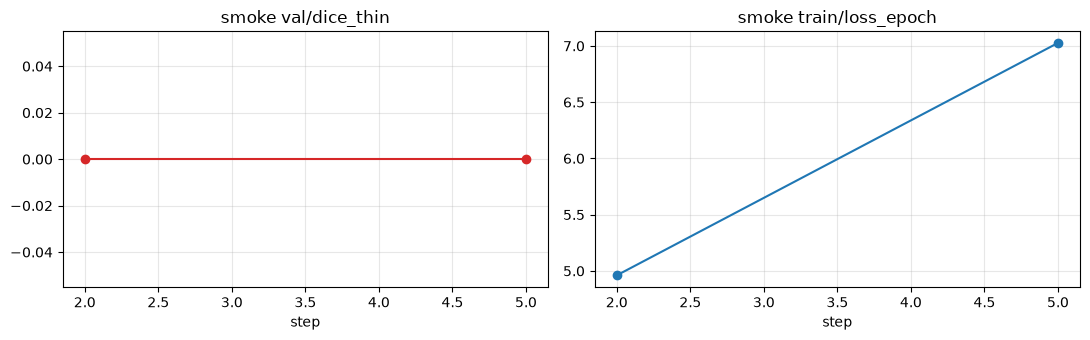

In [20]:
section("6. train.py --smoke — real end-to-end fit")

SMOKE_NAME = "pipeline_test_smoke"
SMOKE_DIR = REPO / "runs" / "pipeline_tests" / SMOKE_NAME
smoke_cmd = [
    PY, "cornerstone_finetune/train.py",
    "--config", "cornerstone_finetune/configs/core5.yaml",
    "--smoke",
    "--set", "run_name=pipeline_test",
    "--set", "run_root=./runs/pipeline_tests",
]

if (SMOKE_DIR / "checkpoints" / "last.ckpt").exists():
    print("smoke run already present -- skipping (delete", SMOKE_DIR, "to re-run)")
else:
    print("running:", " ".join(smoke_cmd))
    r = subprocess.run(smoke_cmd, capture_output=True, text=True, timeout=1200)
    check("train.py --smoke exits 0", r.returncode == 0, f"rc={r.returncode}")
    print("... stdout tail ...")
    print("\n".join(r.stdout.strip().splitlines()[-25:]))
    if r.returncode != 0:
        print("... stderr tail ...")
        print("\n".join(r.stderr.strip().splitlines()[-25:]))

check("smoke: checkpoints/last.ckpt written", (SMOKE_DIR / "checkpoints" / "last.ckpt").exists())
check("smoke: tb event file written", list((SMOKE_DIR / "tb").glob("version_*/events*")))
check("smoke: resolved_config.yaml written", (SMOKE_DIR / "resolved_config.yaml").exists())
check("smoke: split.json written", (SMOKE_DIR / "split.json").exists())

# read the logged metrics back out of the tb events
from tensorboard.backend.event_processing import event_accumulator as E
files = sorted((SMOKE_DIR / "tb").glob("version_*/events*"))
smoke_metrics = {}
for f in files:
    ea = E.EventAccumulator(str(f), size_guidance={"scalars": 0})
    ea.Reload()
    for tag in ea.Tags()["scalars"]:
        smoke_metrics.setdefault(tag, {})
        for s in ea.Scalars(tag):
            smoke_metrics[tag][s.step] = s.value

has_val = "val/dice_thin" in smoke_metrics and len(smoke_metrics["val/dice_thin"]) >= 2
check("smoke: val metrics logged (dice_thin, 2 epochs)", has_val,
      str(sorted(smoke_metrics)))
if has_val:
    last_thin = max(smoke_metrics["val/dice_thin"].values())
    last_loss = max(smoke_metrics["val/loss"].values())
    check("smoke: val/dice_thin finite (0 expected: 2 epochs keep the head at its prior)",
          math.isfinite(last_thin) and last_thin < 0.05, f"{last_thin:.4f}")
    check("smoke: val/loss finite and sane", math.isfinite(last_loss) and last_loss < 10, f"{last_loss:.3f}")
    steps = sorted(smoke_metrics["val/dice_thin"])
    fig, ax = plt.subplots(1, 2, figsize=(11, 3.5))
    ax[0].plot(steps, [smoke_metrics["val/dice_thin"][s] for s in steps], "o-", color="tab:red")
    ax[0].set_title("smoke val/dice_thin"); ax[0].set_xlabel("step")
    ax[1].plot(sorted(smoke_metrics["train/loss_epoch"]),
               [smoke_metrics["train/loss_epoch"][s] for s in sorted(smoke_metrics["train/loss_epoch"])],
               "o-", color="tab:blue")
    ax[1].set_title("smoke train/loss_epoch"); ax[1].set_xlabel("step")
    plt.tight_layout(); plt.show()


7. predict.py — full inference + scoring vs ground truth
predictions already present -- skipping (delete /home/lois/tfm/runs/pipeline_tests/predictions to re-run)
PASS  every test case has every channel mask


,liver,portal_tree,ivc,aorta,vessels
case,,,,,
RMV2025_0003_CT_UTV_VEP_P,0.896,0.605,0.849,0.790,0.597
RMV2025_0004_CT_UTV_VEP_N,0.861,0.719,0.824,0.634,0.665
RMV2025_0010_CT_UTV_VEP_U,0.908,0.511,0.820,0.826,0.625
RMV2025_0015_CT_UTV_VEP_K,0.946,0.588,0.877,0.819,0.656
RMV2026_0035_CT_UTV_VEP_G,0.942,0.632,0.806,0.900,0.627


pooled source-grid dice: {'liver': 0.9117, 'portal_tree': 0.627, 'ivc': 0.8323, 'aorta': 0.7752, 'vessels': 0.6376, 'thin': 0.699, 'bulk': 0.8435, 'mean': 0.7568}
PASS  source-grid liver dice close to logged test/liver  -- 0.912 vs 0.910
PASS  source-grid portal_tree dice close to logged test/portal_tree  -- 0.627 vs 0.610
PASS  source-grid ivc dice close to logged test/ivc  -- 0.832 vs 0.829
PASS  source-grid aorta dice close to logged test/aorta  -- 0.775 vs 0.779
PASS  source-grid vessels dice close to logged test/vessels  -- 0.638 vs 0.630
PASS  thin dice close to logged test/dice_thin  -- 0.699 vs 0.690
PASS  registered to ground truth (liver dice high)  -- 0.912


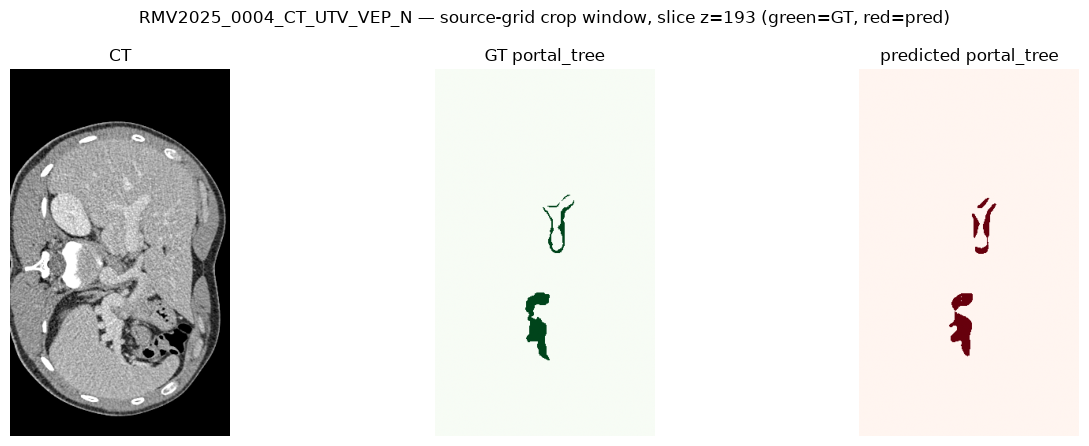

In [21]:
section("7. predict.py — full inference + scoring vs ground truth")

import nibabel as nib
from nibabel.orientations import axcodes2ornt, io_orientation, ornt_transform
from predict import channel_to_filename
from labels import channel_names

CKPT = REPO / "runs/cornerstone/core5_paper_cldice/checkpoints/epoch263-val_dice_thin0.6832.ckpt"
OUT = REPO / "runs" / "pipeline_tests" / "predictions"
pred_cmd = [PY, "cornerstone_finetune/predict.py", "--checkpoint", str(CKPT),
            "--split", "test", "--out", str(OUT)]

if OUT.exists() and any(OUT.iterdir()):
    print("predictions already present -- skipping (delete", OUT, "to re-run)")
else:
    print("running:", " ".join(pred_cmd))
    r = subprocess.run(pred_cmd, capture_output=True, text=True, timeout=1800)
    check("predict.py exits 0", r.returncode == 0, f"rc={r.returncode}")
    print(r.stdout[-1500:])
    if r.returncode != 0:
        print("... stderr tail ..."); print("\n".join(r.stderr.strip().splitlines()[-20:]))

split = json.loads((REPO / "runs/cornerstone/core5_paper_cldice/split.json").read_text())
test_cases = split["test"]
manifest = json.loads((PREPARED / "manifest.json").read_text())
metas = {m["case"]: m for m in manifest["cases"]}
channels = get_channels("core5")
names = channel_names(channels)

# ---- structural checks of the written masks ------------------------------
n_files_ok = all((OUT / c / f"{channel_to_filename(n)}.nii.gz").exists()
                 for c in test_cases for n in names)
check("every test case has every channel mask", n_files_ok)

def crop_slices(m):
    src_shape, src_aff = m["source_shape"], np.asarray(m["source_affine"])
    ras_ornt = ornt_transform(io_orientation(src_aff), axcodes2ornt(("R", "A", "S")))
    lo, hi = m["ras_crop_origin"], m["ras_crop_end"]
    llo, lhi = [0, 0, 0], [0, 0, 0]
    for ras_ax, (src_ax, flip) in enumerate(ras_ornt):
        src_ax, flip = int(src_ax), int(flip)
        rlo, rhi = int(lo[ras_ax]), int(hi[ras_ax])
        if flip > 0:
            llo[src_ax], lhi[src_ax] = rlo, rhi
        else:
            llo[src_ax], lhi[src_ax] = src_shape[src_ax] - rhi, src_shape[src_ax] - rlo
    return tuple(slice(int(a), int(b)) for a, b in zip(llo, lhi))

# ---- per-channel Dice vs ground-truth masks (source grid, crop window) ----
inter, denom = {}, {}
per_case = []
for case in test_cases:
    m = metas[case]
    gt = np.asarray(nib.load(str(MASKS / f"{case}_mask.nii.gz")).dataobj)
    sl = crop_slices(m)
    gt_crop = gt[sl]
    row = {"case": case}
    for i, (n, ch) in enumerate(zip(names, channels)):
        tgt = np.zeros(gt_crop.shape, bool)
        for s in ch.sources:
            tgt |= gt_crop == s
        pred = np.asarray(nib.load(str(OUT / case / f"{channel_to_filename(n)}.nii.gz")).dataobj)[sl].astype(bool)
        i_ = int((pred & tgt).sum()); d = int(pred.sum() + tgt.sum())
        inter[n] = inter.get(n, 0) + i_; denom[n] = denom.get(n, 0) + d
        row[n] = 2 * i_ / d if d else float("nan")
    per_case.append(row)

dice = {n: 2 * inter[n] / denom[n] for n in names}
dice["thin"] = np.nanmean([dice[n] for n in ("portal_tree", "ivc", "vessels")])
dice["bulk"] = np.nanmean([dice[n] for n in ("liver", "aorta")])
dice["mean"] = np.nanmean([dice[n] for n in names])
display(pd.DataFrame(per_case).set_index("case").round(3))
print("pooled source-grid dice:", {k: round(v, 4) for k, v in dice.items()})

# ---- compare against the trainer's logged test metrics (prepared grid) ------
ea = E.EventAccumulator(str(sorted((REPO / "runs/cornerstone/core5_paper_cldice/tb/version_1").glob("events*.1"))[0]),
                        size_guidance={"scalars": 0})
ea.Reload()
logged = {}
for tag in ea.Tags()["scalars"]:
    evs = ea.Scalars(tag)
    if evs and "/" in tag:
        logged[tag.split("/", 1)[1]] = evs[-1].value
for n in names:
    d_here, d_log = dice[n], logged.get(f"dice_{n}", float("nan"))
    check(f"source-grid {n} dice close to logged test/{n}",
          abs(d_here - d_log) < 0.08, f"{d_here:.3f} vs {d_log:.3f}")
check("thin dice close to logged test/dice_thin",
      abs(dice["thin"] - logged["dice_thin"]) < 0.08, f"{dice['thin']:.3f} vs {logged['dice_thin']:.3f}")
check("registered to ground truth (liver dice high)", dice["liver"] > 0.75, f"{dice['liver']:.3f}")

# ---- visual overlay on the richest case -------------------------------------
best_case = max(per_case, key=lambda r: r["portal_tree"])
case = best_case["case"]
m = metas[case]
sl = crop_slices(m)
# the masks and predictions live on the *source* grid -- load the source CT
ct = np.asarray(nib.load(str(REPO / "data/0_test_nifti/imagesTs" / f"{case}.nii.gz")).dataobj)[sl]
gt = np.asarray(nib.load(str(MASKS / f"{case}_mask.nii.gz")).dataobj)[sl]
preds = {n: np.asarray(nib.load(str(OUT / case / f"{channel_to_filename(n)}.nii.gz")).dataobj)[sl]
         for n in names}
portal_gt = np.zeros(gt.shape, bool)
for s in get_channels("core5")[1].sources:
    portal_gt |= gt == s
z = int(np.argmax(portal_gt.sum(axis=(0, 1))))
img = np.clip((ct[..., z] + 175) / 425, 0, 1)
rgb = np.stack([img, img, img], -1)
rgb[..., 0] = np.clip(rgb[..., 0] + 0.6 * preds["portal_tree"][..., z], 0, 1)
rgb[..., 1] = np.clip(rgb[..., 1] + 0.6 * portal_gt[..., z], 0, 1)
fig, axes = plt.subplots(1, 3, figsize=(14, 4.5))
axes[0].imshow(img, cmap="gray"); axes[0].set_title("CT")
axes[1].imshow(portal_gt[..., z], cmap="Greens"); axes[1].set_title("GT portal_tree")
axes[2].imshow(preds["portal_tree"][..., z], cmap="Reds"); axes[2].set_title("predicted portal_tree")
for ax in axes:
    ax.axis("off")
fig.suptitle(f"{case} — source-grid crop window, slice z={z} (green=GT, red=pred)")
fig.tight_layout(); plt.show()

## 8. Inference visualizations — predictions vs ground truth

Same best test case as section 7 (most `portal_tree` ground truth):

- **8a** — 2D slices: every channel, GT vs prediction, on the three orthogonal views
  (slice chosen where that channel's GT has most foreground)
- **8b** — RGB composites (CT + GT in green + prediction in red) on the 3 views
- **8c** — 3D volumes: marching-cubes surfaces of the thin-channel union
  (portal_tree + ivc + vessels), GT vs prediction, plus a rotating overlay animation



8a. 2D slices — GT vs prediction, every channel, 3 views


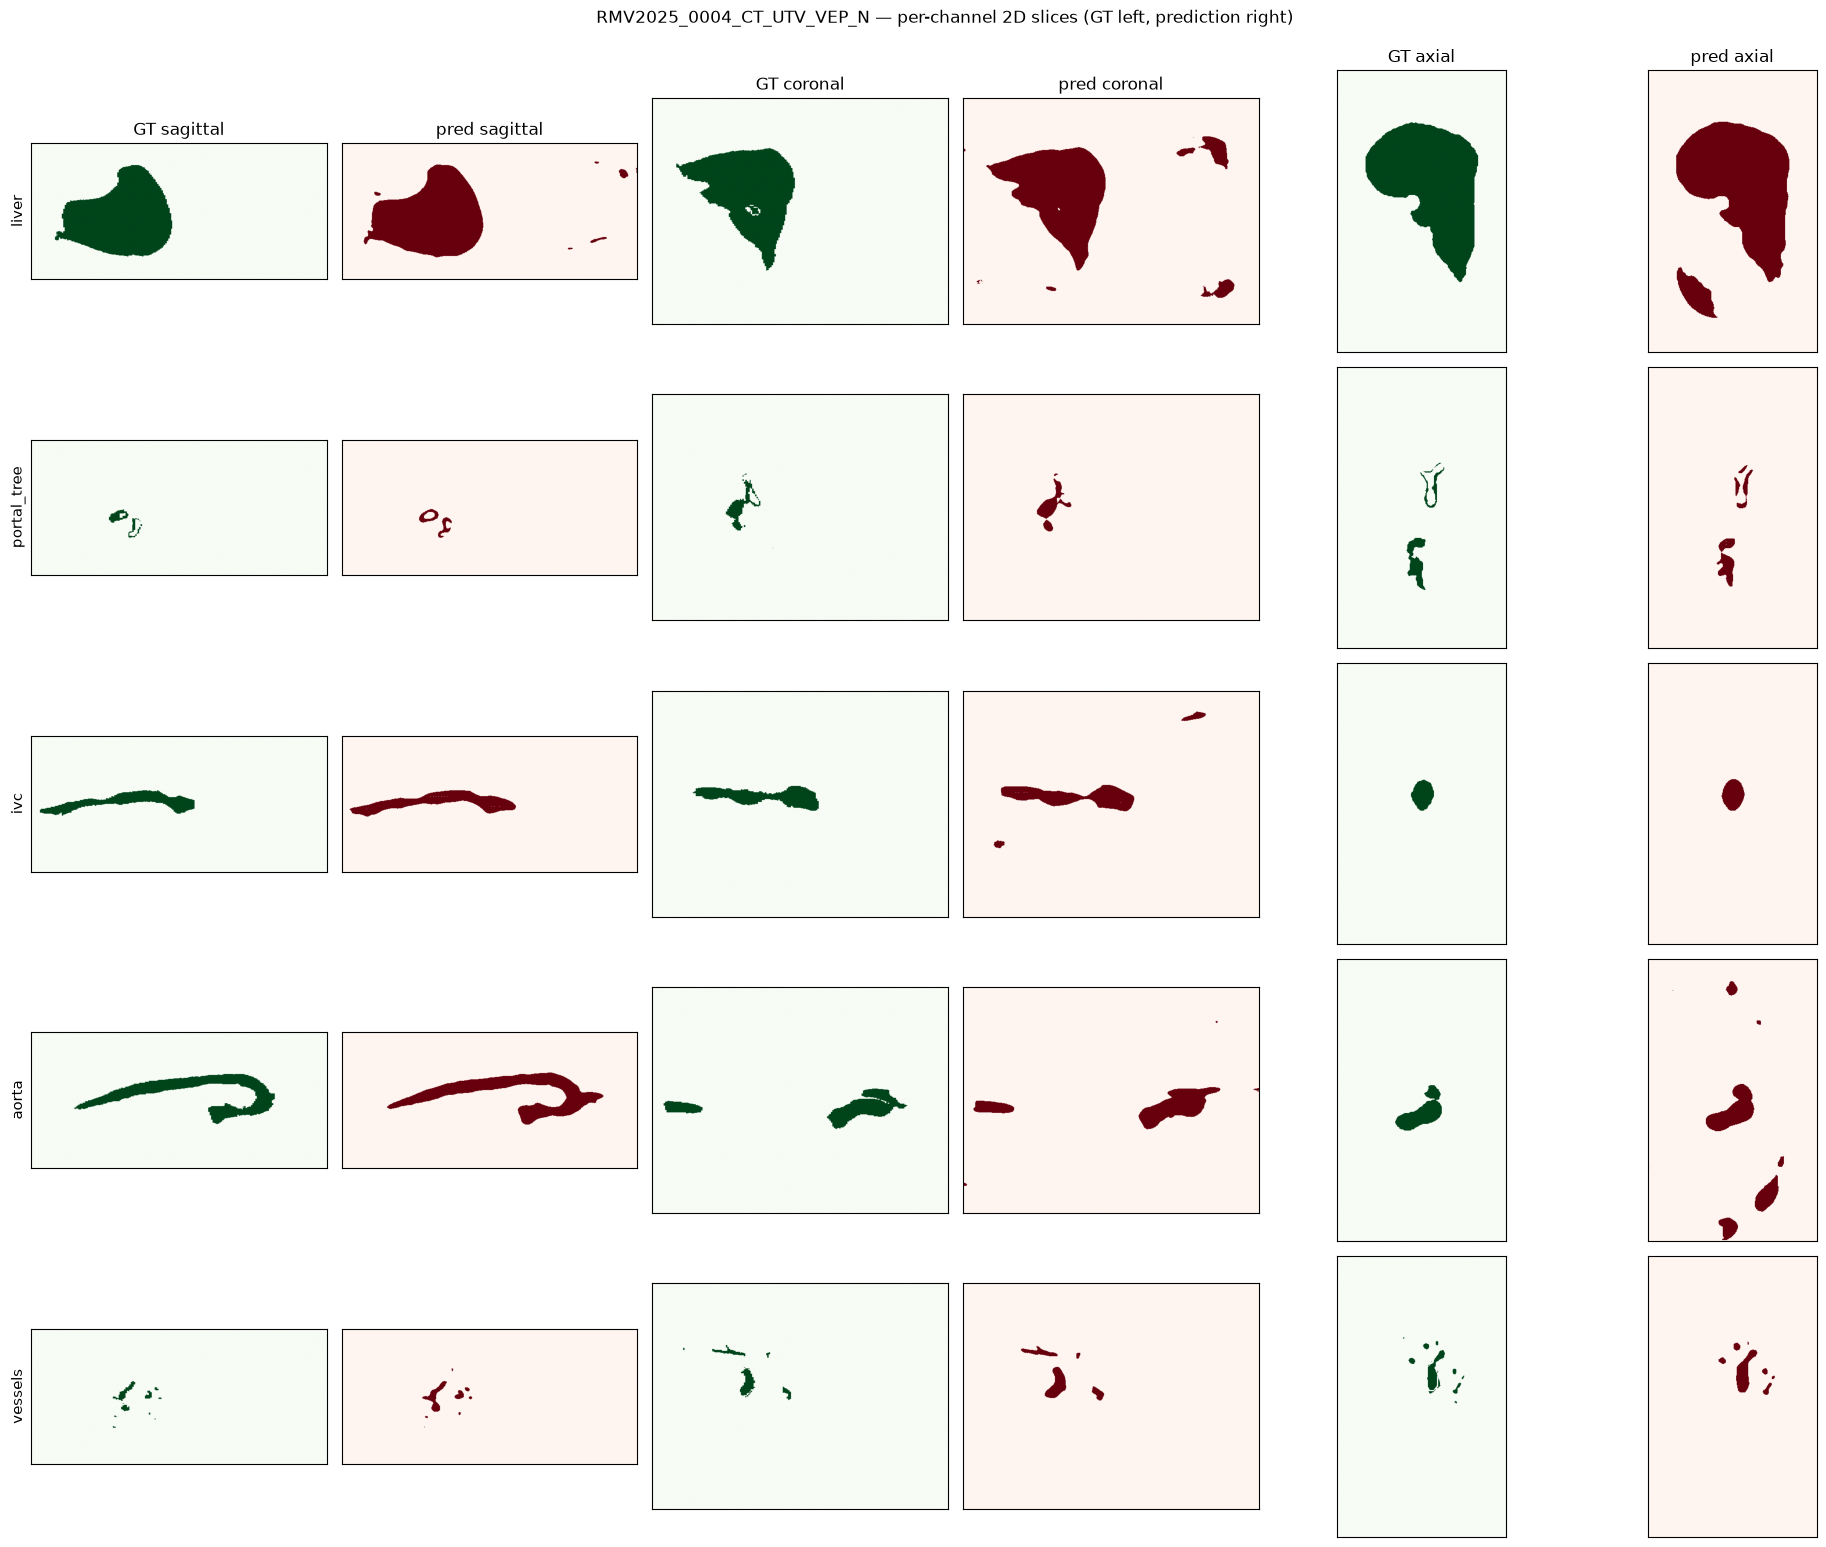

In [22]:
section("8a. 2D slices — GT vs prediction, every channel, 3 views")

ct = np.asarray(nib.load(str(REPO / "data/0_test_nifti/imagesTs" / f"{case}.nii.gz")).dataobj)[sl].astype(np.float32)
gt_map = np.asarray(nib.load(str(MASKS / f"{case}_mask.nii.gz")).dataobj)[sl]

def channel_target(mask, ch):
    out = np.zeros(mask.shape, bool)
    for s in ch.sources:
        out |= mask == s
    return out

gt_ch = {n: channel_target(gt_map, ch) for n, ch in zip(names, channels)}
pred_ch = {n: np.asarray(nib.load(str(OUT / case / f"{channel_to_filename(n)}.nii.gz")).dataobj)[sl].astype(bool)
           for n in names}

def best_slice(mask, axis):
    """Index along `axis` with the most channel foreground."""
    keep = tuple(i for i in range(3) if i != axis)
    return int(np.argmax(mask.sum(axis=keep)))

VIEWS = [(0, "sagittal"), (1, "coronal"), (2, "axial")]
fig, axes = plt.subplots(len(names), 6, figsize=(19, 3.1 * len(names)))
for r, n in enumerate(names):
    for c, (axis, _) in enumerate(VIEWS):
        z = best_slice(gt_ch[n], axis)
        axes[r, 2 * c].imshow(np.take(gt_ch[n], z, axis=axis), cmap="Greens", vmin=0, vmax=1)
        axes[r, 2 * c + 1].imshow(np.take(pred_ch[n], z, axis=axis), cmap="Reds", vmin=0, vmax=1)
        if r == 0:
            axes[r, 2 * c].set_title(f"GT {VIEWS[c][1]}")
            axes[r, 2 * c + 1].set_title(f"pred {VIEWS[c][1]}")
    axes[r, 0].set_ylabel(n, fontsize=11)
for ax in axes.ravel():
    ax.set_xticks([]); ax.set_yticks([])
fig.suptitle(f"{case} — per-channel 2D slices (GT left, prediction right)", y=0.995)
fig.tight_layout()
plt.show()


8b. RGB composites — CT + GT (green) + prediction (red)


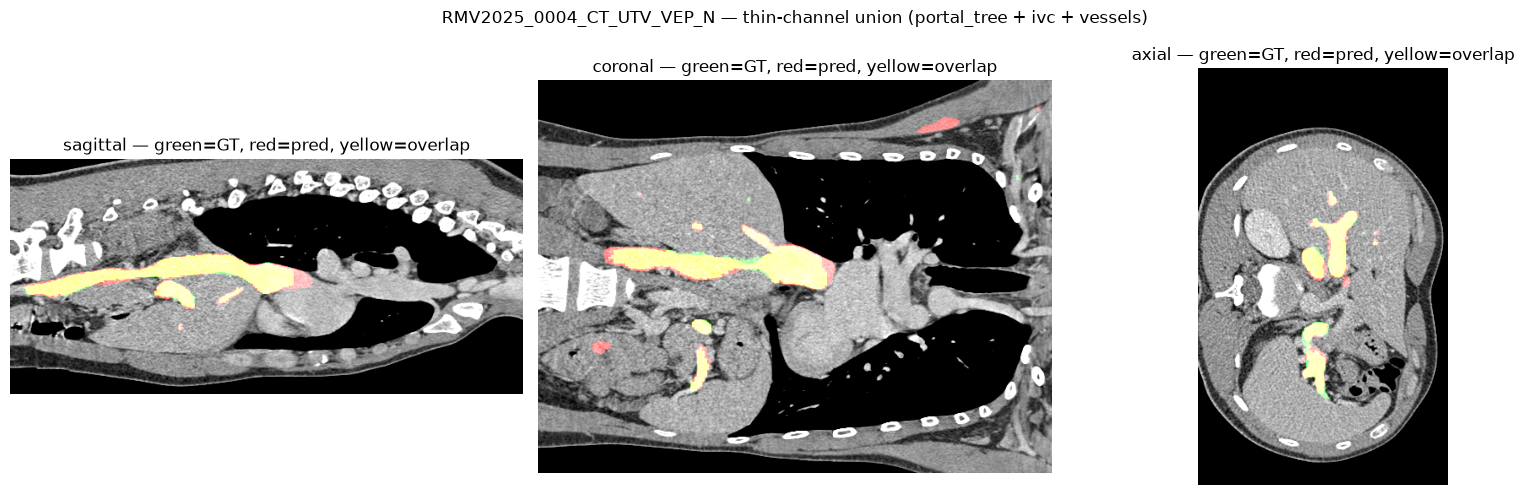

In [23]:
section("8b. RGB composites — CT + GT (green) + prediction (red)")

thin_gt = gt_ch["portal_tree"] | gt_ch["ivc"] | gt_ch["vessels"]
thin_pred = pred_ch["portal_tree"] | pred_ch["ivc"] | pred_ch["vessels"]
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
for ax, (axis, name) in zip(axes, VIEWS):
    z = best_slice(thin_gt, axis)
    s = tuple(slice(None) if i != axis else z for i in range(3))
    im = np.clip((ct[s] + 175) / 425, 0, 1)
    rgb = np.stack([im, im, im], -1)
    rgb[..., 0] = np.clip(rgb[..., 0] + 0.55 * thin_pred[s], 0, 1)
    rgb[..., 1] = np.clip(rgb[..., 1] + 0.55 * thin_gt[s], 0, 1)
    ax.imshow(rgb)
    ax.set_title(name + " — green=GT, red=pred, yellow=overlap")
    ax.axis("off")
fig.suptitle(f"{case} — thin-channel union (portal_tree + ivc + vessels)", y=0.98)
fig.tight_layout()
plt.show()


8c. 3D volumes — marching-cubes surfaces, GT vs prediction
meshes: GT 56314 tris, pred 67758 tris, liver 57716 tris


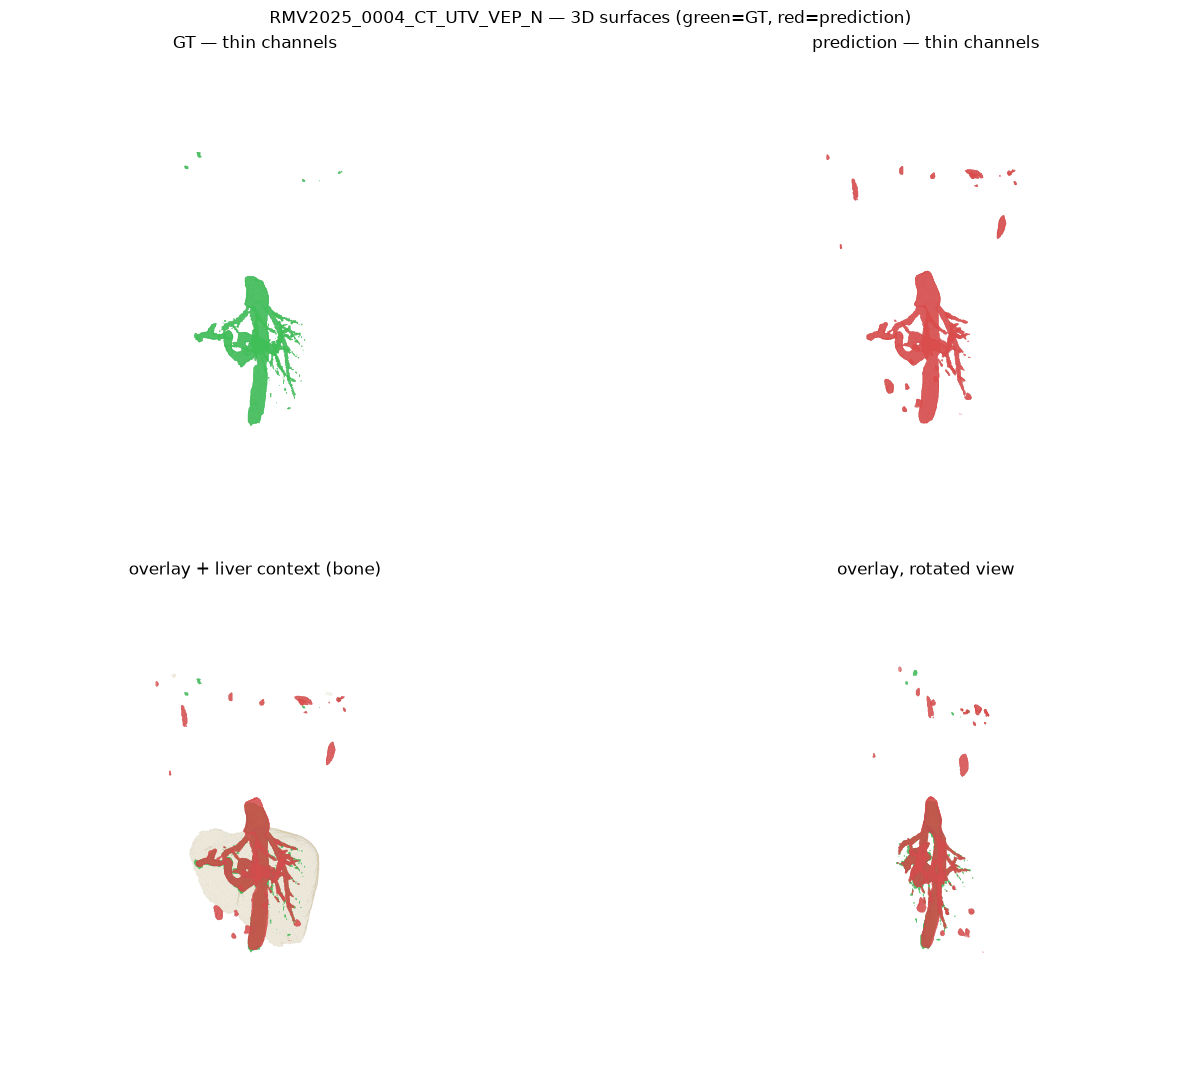

In [24]:
section("8c. 3D volumes — marching-cubes surfaces, GT vs prediction")

from skimage.measure import marching_cubes
from mpl_toolkits.mplot3d.art3d import Poly3DCollection

DS = 2                       # downsample of the source-grid crop for meshing
thin_gt_ds = thin_gt[::DS, ::DS, ::DS]
thin_pred_ds = thin_pred[::DS, ::DS, ::DS]
verts_g, faces_g, _, _ = marching_cubes(thin_gt_ds, level=0.5)
verts_p, faces_p, _, _ = marching_cubes(thin_pred_ds, level=0.5)
liver_gt_ds = gt_ch["liver"][::3, ::3, ::3]
verts_l, faces_l, _, _ = marching_cubes(liver_gt_ds, level=0.5)
verts_l = verts_l * 1.5     # liver meshed on the 3x grid -> back to the 2x grid
print(f"meshes: GT {len(faces_g)} tris, pred {len(faces_p)} tris, liver {len(faces_l)} tris")

GREEN, RED, BONE = (0.25, 0.75, 0.35), (0.85, 0.3, 0.3), (0.85, 0.8, 0.65)
ELEV, AZIM = 18.0, 115.0

def show_mesh(ax, verts, faces, color, alpha=1.0):
    pc = Poly3DCollection(verts[faces], alpha=alpha, linewidth=0, shade=False)
    pc.set_facecolor(color)
    ax.add_collection3d(pc)

def set_limits(ax, verts):
    lo, hi = verts.min(0), verts.max(0)
    c = (lo + hi) / 2
    r = float((hi - lo).max()) / 2 * 1.05
    ax.set_xlim(c[0] - r, c[0] + r); ax.set_ylim(c[1] - r, c[1] + r); ax.set_zlim(c[2] - r, c[2] + r)
    ax.set_box_aspect((1, 1, 1))

fig = plt.figure(figsize=(15, 11))
ax = fig.add_subplot(2, 2, 1, projection="3d")
show_mesh(ax, verts_g, faces_g, GREEN); ax.view_init(ELEV, AZIM); ax.set_axis_off()
ax.set_title("GT — thin channels", fontsize=12)
set_limits(ax, verts_g)

ax = fig.add_subplot(2, 2, 2, projection="3d")
show_mesh(ax, verts_p, faces_p, RED); ax.view_init(ELEV, AZIM); ax.set_axis_off()
ax.set_title("prediction — thin channels", fontsize=12)
set_limits(ax, verts_g)

ax = fig.add_subplot(2, 2, 3, projection="3d")
show_mesh(ax, verts_l, faces_l, BONE, alpha=0.22)
show_mesh(ax, verts_g, faces_g, GREEN, alpha=0.85)
show_mesh(ax, verts_p, faces_p, RED, alpha=0.85)
ax.view_init(ELEV, AZIM); ax.set_axis_off()
ax.set_title("overlay + liver context (bone)", fontsize=12)
set_limits(ax, verts_g)

ax = fig.add_subplot(2, 2, 4, projection="3d")
show_mesh(ax, verts_g, faces_g, GREEN, alpha=0.85)
show_mesh(ax, verts_p, faces_p, RED, alpha=0.85)
ax.view_init(ELEV, AZIM + 45); ax.set_axis_off()
ax.set_title("overlay, rotated view", fontsize=12)
set_limits(ax, verts_g)

fig.suptitle(f"{case} — 3D surfaces (green=GT, red=prediction)", y=0.98)
plt.tight_layout()
plt.show()


8d. rotating 3D overlay animation (GIF)


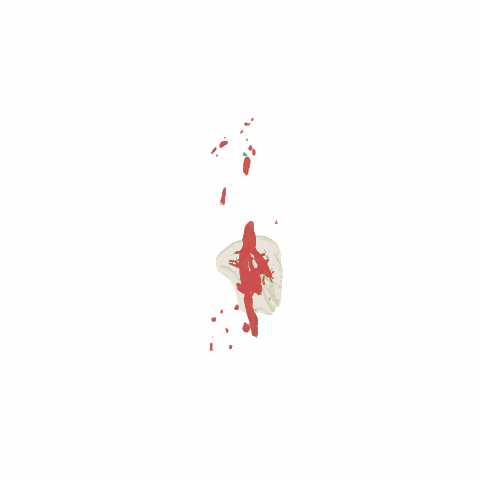

PASS  rotating overlay GIF written  -- thin_overlay_rot.gif (99 KB, 24 frames)


In [25]:
section("8d. rotating 3D overlay animation (GIF)")

from PIL import Image as PILImage
from IPython.display import Image as IPyImage
import io

gif_dir = REPO / "runs/pipeline_tests/figures"
gif_dir.mkdir(parents=True, exist_ok=True)
gif_path = gif_dir / "thin_overlay_rot.gif"

FRAMES = 24
fig = plt.figure(figsize=(6, 6))
ax = fig.add_subplot(111, projection="3d")
show_mesh(ax, verts_l, faces_l, BONE, alpha=0.2)
show_mesh(ax, verts_g, faces_g, GREEN, alpha=0.95)
show_mesh(ax, verts_p, faces_p, RED, alpha=0.95)
ax.set_axis_off()
set_limits(ax, verts_g)

frames = []
for az in np.linspace(0, 360, FRAMES, endpoint=False):
    ax.view_init(elev=18, azim=az)
    buf = io.BytesIO()
    fig.savefig(buf, format="png", dpi=80)
    buf.seek(0)
    frames.append(PILImage.open(buf).convert("P", palette=PILImage.ADAPTIVE, colors=128).copy())
plt.close(fig)

frames[0].save(gif_path, save_all=True, append_images=frames[1:],
               duration=120, loop=0, optimize=True)
display(IPyImage(filename=str(gif_path)))
check("rotating overlay GIF written", gif_path.exists(),
      f"{gif_path.name} ({gif_path.stat().st_size / 1e3:.0f} KB, {FRAMES} frames)")

## 9. Class colours & Couinaud segments

- **9a / 9b** — each of the 5 detected classes in its own colour, as 2D overlays on the CT
  and as 3D surfaces, for test case `RMV2025_0003_CT_UTV_VEP_P` (the network's predictions)
- **9c** — the Couinaud stage: the `continuity/couinaud` pipeline run over the same case's
  full 15-class label set (extracted from `couinaud_train.tar.gz`), producing the eight
  Couinaud segments, its sanity checks and its own figures
- **9d / 9e** — the 8 segments in their reference colours: 2D overlays in the recovered
  anatomical frame with roman numerals, and 3D surfaces with a rotating view

The Couinaud stage consumes per-class labels (portal pedicles + hepatic veins) that the
5-channel network does not output, so 9c-9e run on the case's full label set, while
9a-9b show the network's own predictions. The cornerstones masks cannot feed this stage
either: their pedicle/vein labels are remnants (e.g. `classPediculoPortalAnteriorDerecho`
= 21 voxels in this case), which leaves segments V/VIII empty.



9a. 2D — one colour per detected class (predictions)


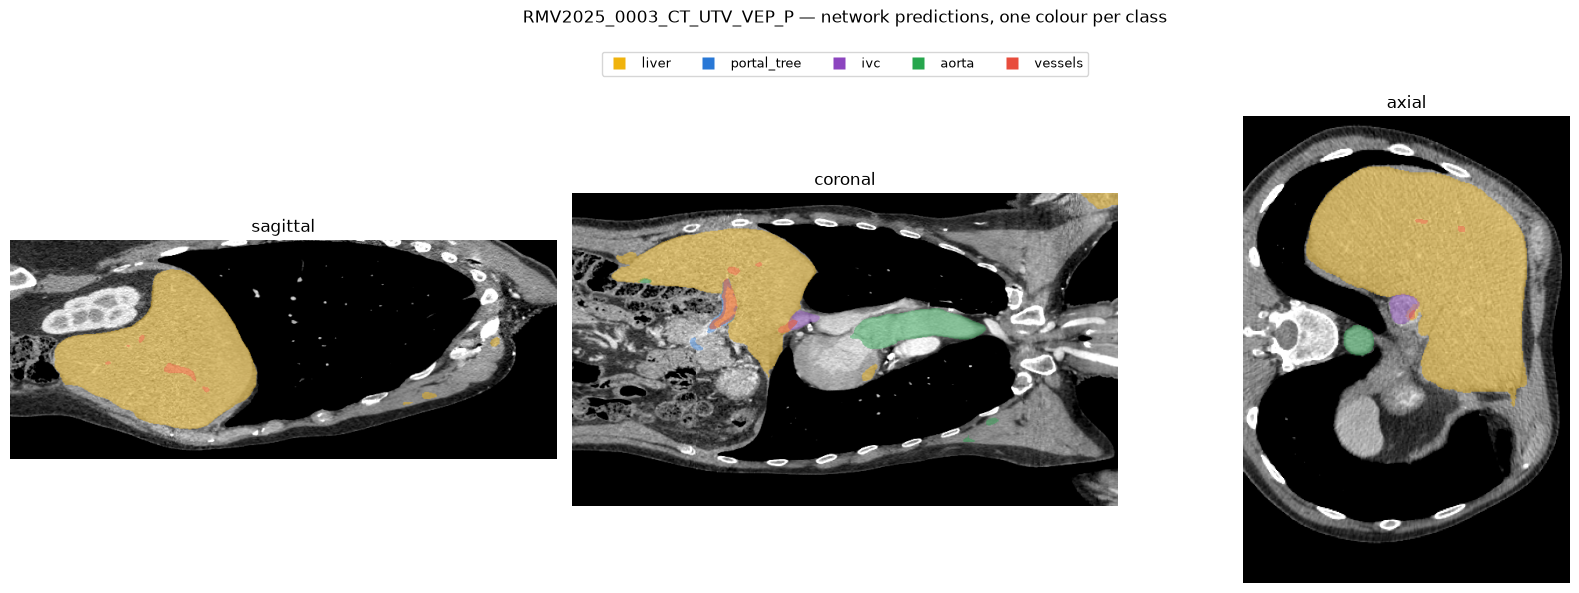

In [26]:
section("9a. 2D — one colour per detected class (predictions)")

CLASS_COLORS = {
    "liver":       (0.94, 0.70, 0.05),
    "portal_tree": (0.16, 0.47, 0.84),
    "ivc":         (0.55, 0.27, 0.75),
    "aorta":       (0.15, 0.65, 0.30),
    "vessels":     (0.91, 0.30, 0.24),
}
case3 = "RMV2025_0003_CT_UTV_VEP_P"
m3 = metas[case3]
sl3 = crop_slices(m3)
ct3 = np.asarray(nib.load(str(REPO / "data/0_test_nifti/imagesTs" / f"{case3}.nii.gz")).dataobj)[sl3].astype(np.float32)
pred3 = {n: np.asarray(nib.load(str(OUT / case3 / f"{channel_to_filename(n)}.nii.gz")).dataobj)[sl3].astype(bool)
         for n in names}

fig, axes = plt.subplots(1, 3, figsize=(17, 5.5))
for ax, (axis, vname) in zip(axes, VIEWS):
    z = best_slice(pred3["liver"], axis)
    s = tuple(slice(None) if i != axis else z for i in range(3))
    base = np.clip((ct3[s] + 175) / 425, 0, 1)
    rgb = np.stack([base, base, base], -1)
    for name, col in CLASS_COLORS.items():
        m = pred3[name][s]
        if not m.any():
            continue
        for c in range(3):
            rgb[..., c] = np.clip(rgb[..., c] * (1 - 0.45 * m) + col[c] * 0.45 * m, 0, 1)
    ax.imshow(rgb)
    ax.set_title(vname)
    ax.axis("off")
handles = [plt.Line2D([], [], marker="s", linestyle="", markersize=9,
                      markerfacecolor=c, markeredgecolor="none", label=n)
           for n, c in CLASS_COLORS.items()]
fig.legend(handles=handles, loc="upper center", ncol=5, bbox_to_anchor=(0.5, 1.005), fontsize=9)
fig.suptitle(f"{case3} — network predictions, one colour per class", y=1.07)
fig.tight_layout()
plt.show()


9b. 3D — one coloured surface per detected class
debug pred3 sums: {'liver': 3227027, 'portal_tree': 46592, 'ivc': 153267, 'aorta': 622757, 'vessels': 50312}


class meshes: {'liver': 2, 'portal_tree': 2, 'ivc': 2, 'aorta': 2, 'vessels': 2}


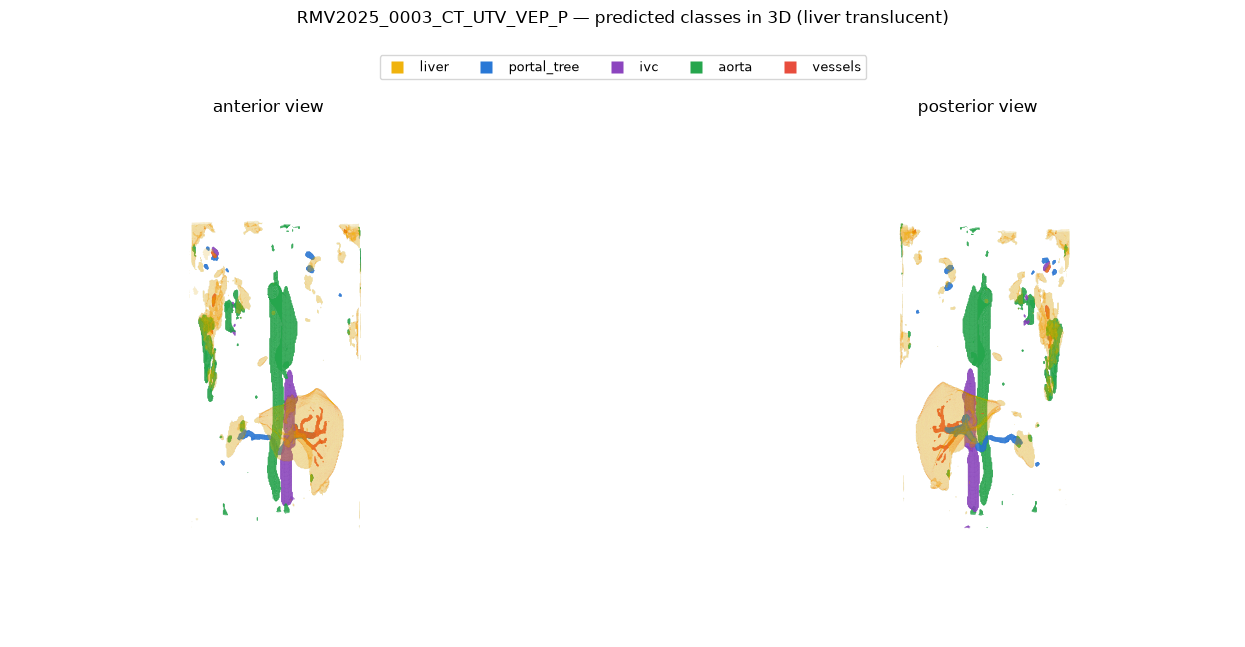

In [27]:
section("9b. 3D — one coloured surface per detected class")

DS3 = 2
print("debug pred3 sums:", {n: int(pred3[n].sum()) for n in names})
meshes3 = {}
for n in names:
    v, f, _, _ = marching_cubes(pred3[n][::DS3, ::DS3, ::DS3], level=0.5)
    meshes3[n] = (v, f)
print("class meshes:", {n: len(f) for n, f in meshes3.items()})

fig = plt.figure(figsize=(15, 6))
for k, (title, azim) in enumerate([("anterior view", 90), ("posterior view", 270)]):
    ax = fig.add_subplot(1, 2, k + 1, projection="3d")
    show_mesh(ax, *meshes3["liver"], CLASS_COLORS["liver"], alpha=0.22)
    for n in names[1:]:
        show_mesh(ax, *meshes3[n], CLASS_COLORS[n], alpha=0.95)
    ax.view_init(12, azim); ax.set_axis_off(); ax.set_title(title)
    set_limits(ax, meshes3["liver"][0])
handles3 = [plt.Line2D([], [], marker="s", linestyle="", markersize=9,
                       markerfacecolor=c, markeredgecolor="none", label=n)
            for n, c in CLASS_COLORS.items()]
fig.legend(handles=handles3, loc="upper center", ncol=5, bbox_to_anchor=(0.5, 1.005), fontsize=9)
fig.suptitle(f"{case3} — predicted classes in 3D (liver translucent)", y=1.07)
plt.tight_layout()
plt.show()


9c. Couinaud stage — the eight segments from the full label set


couinaud output cached -- skipping run (delete /home/lois/tfm/runs/pipeline_tests/couinaud/RMV2025_0003_CT_UTV_VEP_P to re-run)
PASS  couinaud label volume written
PASS  all eight segments produced  -- {'1': 0.7696067310304648, '2': 5.7131273579753135, '3': 3.826046892023986, '4': 15.609691541118048, '5': 25.426781277921084, '6': 25.31985838844028, '7': 12.057919015889286, '8': 11.276968795601528}
PASS  >= 8/12 pipeline sanity checks pass  -- 10/12


,mL,%,% (other mode)
segment,,,
I (caudate),10.99,0.77,0.06
II (left lateral superior),81.59,5.71,6.68
III (left lateral inferior),54.64,3.83,7.93
IV (left medial (quadrate)),222.93,15.61,7.22
V (right anterior inferior),363.13,25.43,43.43
VI (right posterior inferior),361.60,25.32,27.19
VII (right posterior superior),172.20,12.06,1.79
VIII (right anterior superior),161.05,11.28,5.70


voronoi/hybrid agreement: 0.646 | frame: R=axis0- A=axis2+ S=axis1+ (confidence 0.71, margin 0.17)


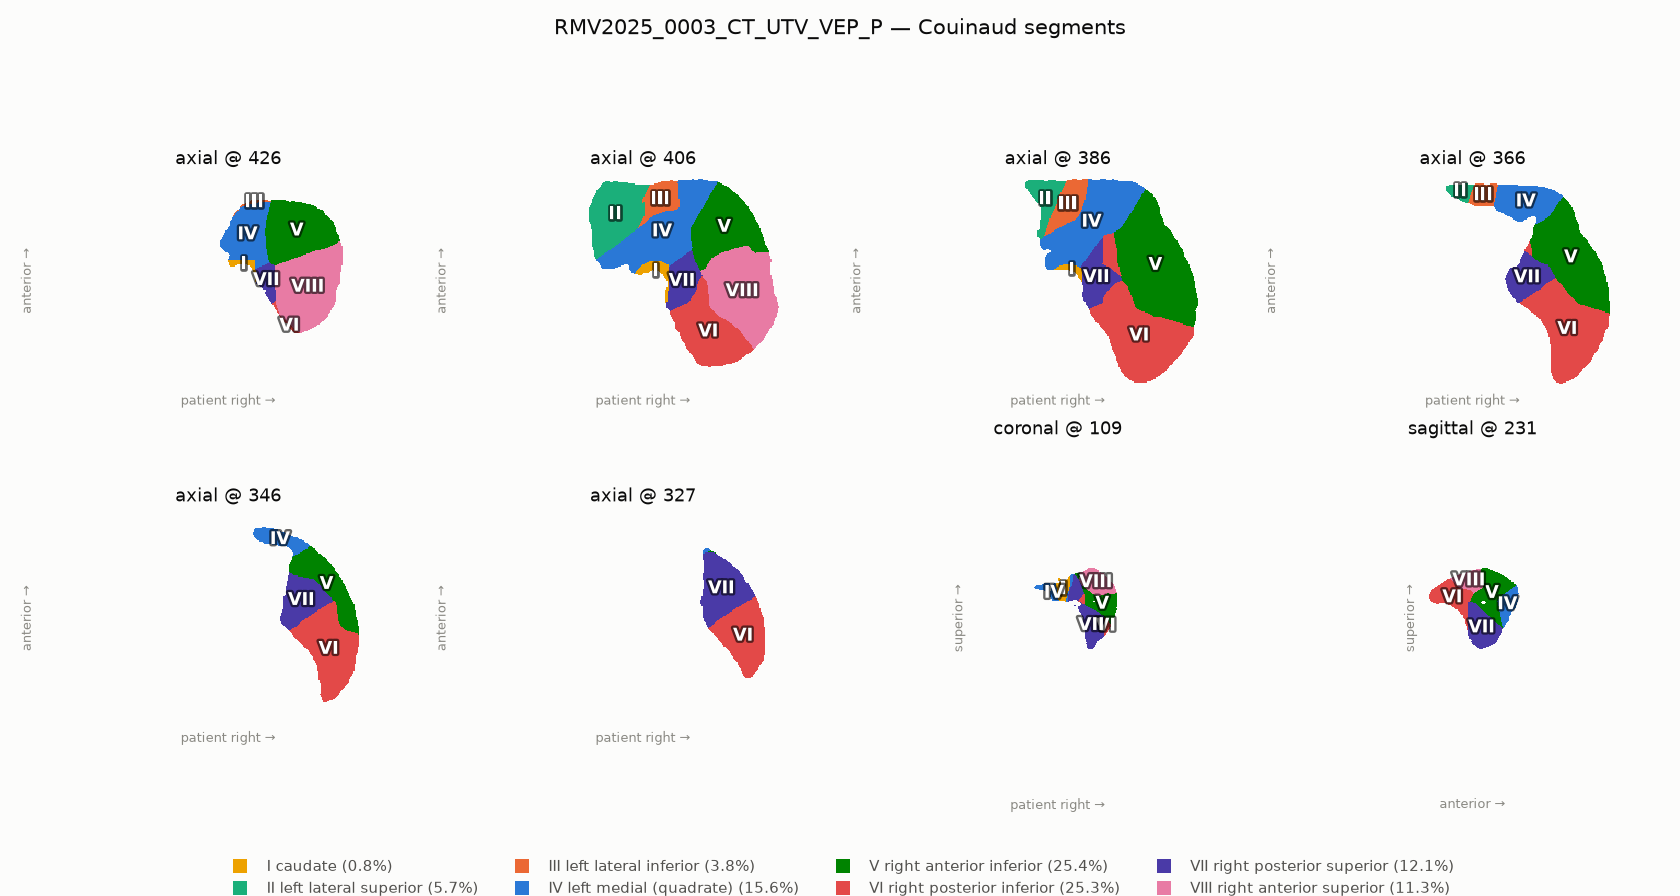

In [28]:
section("9c. Couinaud stage — the eight segments from the full label set")

import tarfile
import sys as _sys
_sys.path.insert(0, str(REPO / "continuity"))
_sys.path.insert(0, str(REPO / "continuity" / "couinaud"))
from couinaud import SEG_NAMES, SEG_DESCRIPTION

COU_SCRIPT = REPO / "runs/pipeline_tests/run_couinaud_case.py"
COU_OUT = REPO / "runs/pipeline_tests/couinaud"
cou_case = "RMV2025_0003_CT_UTV_VEP_P"
cou_dir = REPO / "continuity/data/0_test_nifti" / cou_case
cou_vol = COU_OUT / cou_case / f"{cou_case}_couinaud.nii.gz"

# self-contained: pull the case's per-class labels out of the shipped tarball
if not cou_dir.exists():
    with tarfile.open(REPO / "couinaud_train.tar.gz") as tf:
        for m in tf.getmembers():
            if f"continuity/data/0_test_nifti/{cou_case}/" in m.name and m.name.endswith(".nii.gz"):
                tf.extract(m, REPO)
    check("per-class label cohort extracted from couinaud_train.tar.gz", cou_dir.exists(),
          f"{len(list(cou_dir.glob('class*.nii.gz')))} class files")

if cou_vol.exists():
    print("couinaud output cached -- skipping run (delete", COU_OUT / cou_case, "to re-run)")
else:
    r = subprocess.run([PY, str(COU_SCRIPT), cou_case], capture_output=True, text=True, timeout=1800)
    check("couinaud pipeline exits 0", r.returncode == 0, f"rc={r.returncode}")
    print(r.stdout[-1600:])

check("couinaud label volume written", cou_vol.exists())
cou_summary = json.loads((COU_OUT / cou_case / "summary.json").read_text())
check("all eight segments produced",
      set(cou_summary["volume_pct"]) == {str(s) for s in range(1, 9)},
      str(cou_summary["volume_pct"]))
check(">= 8/12 pipeline sanity checks pass",
      cou_summary["checks"]["passed"] >= 8,
      f"{cou_summary['checks']['passed']}/{cou_summary['checks']['total']}")

rows = [{"segment": f"{SEG_NAMES[s]} ({SEG_DESCRIPTION[s]})",
         "mL": cou_summary["volume_ml"][str(s)],
         "%": cou_summary["volume_pct"][str(s)],
         "% (other mode)": cou_summary["volume_pct_other_mode"][str(s)]}
        for s in range(1, 9)]
display(pd.DataFrame(rows).set_index("segment").round(2))
print("voronoi/hybrid agreement:", round(cou_summary["mode_agreement"], 3),
      "| frame:", cou_summary["frame"])

display(IPyImage(filename=str(COU_OUT / cou_case / "4_segments.png")))


9d. 2D — the eight segments in their reference colours
reoriented segment volume: (341, 192, 695) | R=axis0- A=axis2+ S=axis1+ (confidence 0.71, margin 0.17)


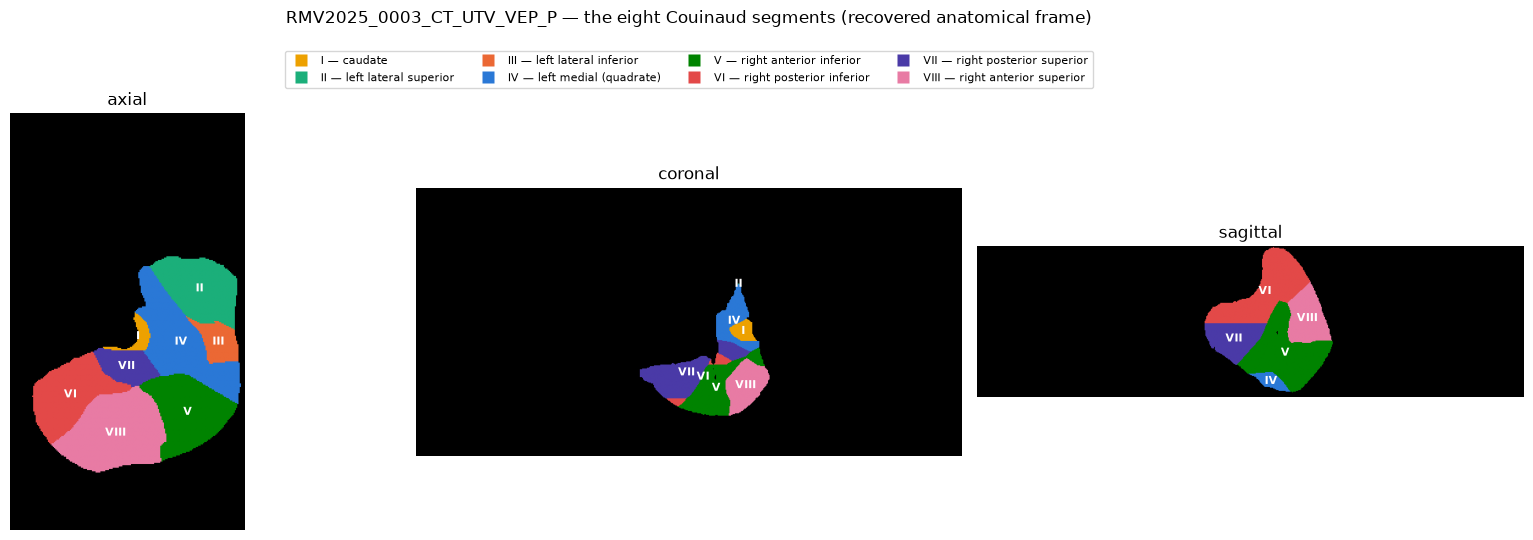

In [29]:
section("9d. 2D — the eight segments in their reference colours")

import matplotlib
import sys as _sys
_sys.path.insert(0, str(REPO / "continuity"))
_sys.path.insert(0, str(REPO / "continuity" / "couinaud"))
from couinaud import SEG_COLOR_LIGHT, SEG_NAMES, SEG_DESCRIPTION, load_case

seg_vol = np.asarray(nib.load(str(cou_vol)).dataobj).astype(np.uint8)
frame = load_case(cou_dir).frame
seg_anat = frame.reorient(seg_vol)          # axes in (R, A, S) order
print("reoriented segment volume:", seg_anat.shape, "|", frame.describe())

seg_rgb = np.zeros((*seg_anat.shape, 3))
for s in range(1, 9):
    col = np.array(matplotlib.colors.to_rgb(SEG_COLOR_LIGHT[s]))
    m = seg_anat == s
    for c in range(3):
        seg_rgb[..., c] = np.where(m, col[c], seg_rgb[..., c])

fig, axes = plt.subplots(1, 3, figsize=(17, 5))
for ax, axis, t in zip(axes, [2, 1, 0], ["axial", "coronal", "sagittal"]):
    z = best_slice(seg_anat > 0, axis)
    s = tuple(slice(None) if i != axis else z for i in range(3))
    ax.imshow(seg_rgb[s])
    for seg in range(1, 9):
        m2d = seg_anat[s] == seg
        if not m2d.any():
            continue
        cy, cx = (float(np.argwhere(m2d)[:, a].mean()) for a in (0, 1))
        ax.text(cx, cy, SEG_NAMES[seg], ha="center", va="center", fontsize=8,
                color="white", fontweight="bold")
    ax.set_title(t)
    ax.axis("off")
handles = [plt.Line2D([], [], marker="s", linestyle="", markersize=8,
                      markerfacecolor=SEG_COLOR_LIGHT[s], markeredgecolor="none",
                      label=f"{SEG_NAMES[s]} — {SEG_DESCRIPTION[s]}") for s in range(1, 9)]
fig.legend(handles=handles, loc="upper center", ncol=4, bbox_to_anchor=(0.5, 1.0), fontsize=8)
fig.suptitle(f"{cou_case} — the eight Couinaud segments (recovered anatomical frame)", y=1.07)
fig.tight_layout()
plt.show()


9e. 3D — segment surfaces + rotating view
segment meshes: {1: 2, 2: 2, 3: 2, 4: 2, 5: 2, 6: 2, 7: 2, 8: 2}


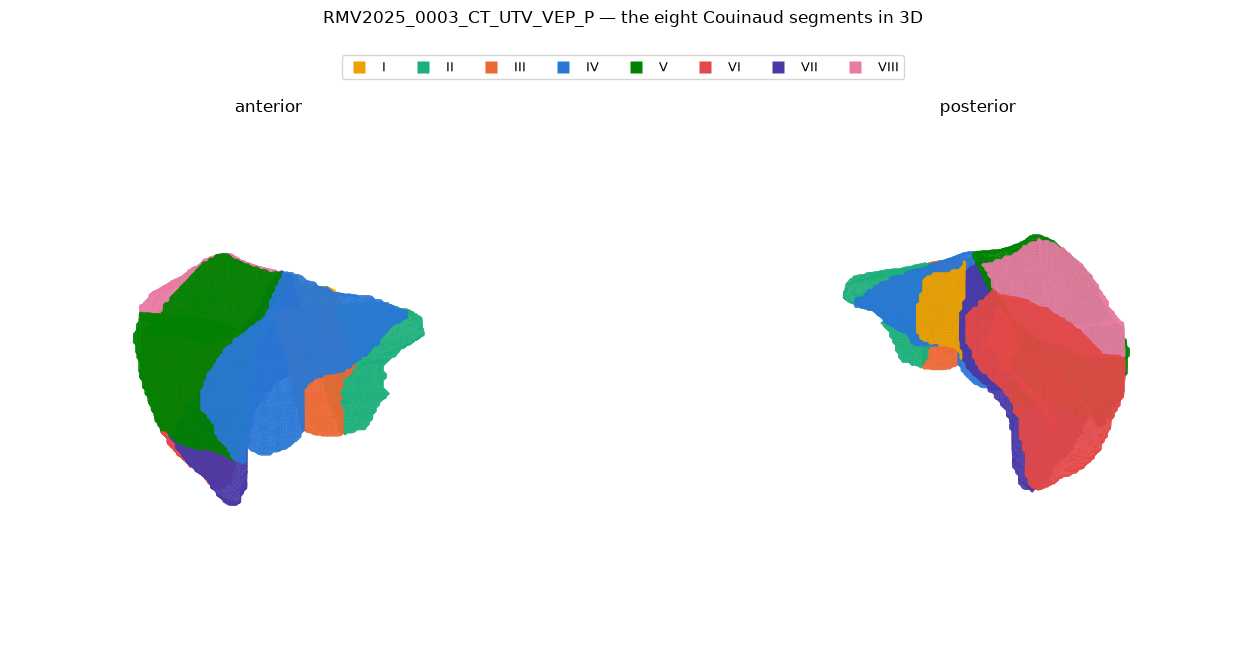

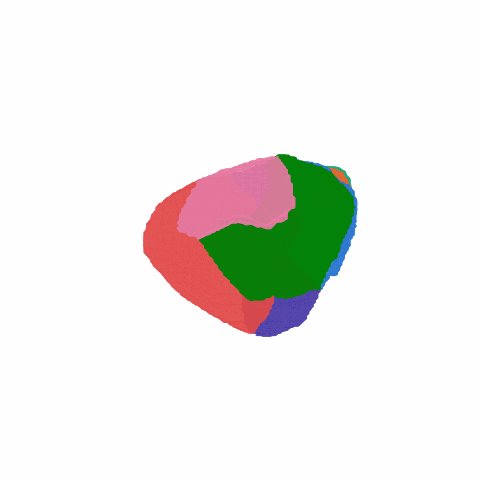

PASS  couinaud segments GIF written  -- couinaud_segments_rot.gif (172 KB, 24 frames)


In [30]:
section("9e. 3D — segment surfaces + rotating view")

import matplotlib

seg_ds = seg_anat[::2, ::2, ::2]
seg_meshes = {}
for s in range(1, 9):
    v, f, _, _ = marching_cubes(seg_ds == s, level=0.5)
    seg_meshes[s] = (v, f)
print("segment meshes:", {s: len(f) for s, f in seg_meshes.items()})
all_v = np.concatenate([v for v, _ in seg_meshes.values()])

fig = plt.figure(figsize=(15, 6))
for k, (title, azim) in enumerate([("anterior", 90), ("posterior", 270)]):
    ax = fig.add_subplot(1, 2, k + 1, projection="3d")
    for s in range(1, 9):
        show_mesh(ax, *seg_meshes[s], matplotlib.colors.to_rgb(SEG_COLOR_LIGHT[s]), alpha=0.95)
    ax.view_init(15, azim); ax.set_axis_off(); ax.set_title(title)
    set_limits(ax, all_v)
handles = [plt.Line2D([], [], marker="s", linestyle="", markersize=8,
                      markerfacecolor=SEG_COLOR_LIGHT[s], markeredgecolor="none",
                      label=SEG_NAMES[s]) for s in range(1, 9)]
fig.legend(handles=handles, loc="upper center", ncol=8, bbox_to_anchor=(0.5, 1.005), fontsize=9)
fig.suptitle(f"{cou_case} — the eight Couinaud segments in 3D", y=1.07)
plt.tight_layout()
plt.show()

gif_path2 = REPO / "runs/pipeline_tests/figures/couinaud_segments_rot.gif"
FRAMES2 = 24
fig = plt.figure(figsize=(6, 6))
ax = fig.add_subplot(111, projection="3d")
for s in range(1, 9):
    show_mesh(ax, *seg_meshes[s], matplotlib.colors.to_rgb(SEG_COLOR_LIGHT[s]), alpha=0.95)
ax.set_axis_off()
set_limits(ax, all_v)
frames2 = []
for az in np.linspace(0, 360, FRAMES2, endpoint=False):
    ax.view_init(elev=15, azim=az)
    buf = io.BytesIO()
    fig.savefig(buf, format="png", dpi=80)
    buf.seek(0)
    frames2.append(PILImage.open(buf).convert("P", palette=PILImage.ADAPTIVE, colors=128).copy())
plt.close(fig)
frames2[0].save(gif_path2, save_all=True, append_images=frames2[1:],
                duration=120, loop=0, optimize=True)
display(IPyImage(filename=str(gif_path2)))
check("couinaud segments GIF written", gif_path2.exists(),
      f"{gif_path2.name} ({gif_path2.stat().st_size / 1e3:.0f} KB, {FRAMES2} frames)")

In [31]:
section("10. verdict")

df = pd.DataFrame(CHECKS)
display(df[["section", "name", "ok", "note"]].set_index("name"))
n_pass, n_fail = int(df["ok"].sum()), int((~df["ok"]).sum())
print(f"\n{n_pass} PASS / {n_fail} FAIL / {len(df)} total")
assert n_fail == 0, f"{n_fail} checks failed -- see table above"

# clean the smoke-run artifacts (the predictions stay as pipeline output)
shutil.rmtree(SMOKE_DIR, ignore_errors=True)
print("smoke run dir cleaned:", not SMOKE_DIR.exists())


10. verdict


,section,ok,note
name,,,
manifest exists with 38 cases,1. prepare_data.py artifacts — data/cornerston...,True,n=38; failed=[]
manifest spacing is 1 mm isotropic,1. prepare_data.py artifacts — data/cornerston...,True,"[1.0, 1.0, 1.0]"
margin 32 mm,1. prepare_data.py artifacts — data/cornerston...,True,
labels.json == LABEL_IDS,1. prepare_data.py artifacts — data/cornerston...,True,
image/label shapes agree with meta (all cases),1. prepare_data.py artifacts — data/cornerston...,True,bad=0
...,...,...,...
rotating overlay GIF written,8d. rotating 3D overlay animation (GIF),True,"thin_overlay_rot.gif (99 KB, 24 frames)"
couinaud label volume written,9c. Couinaud stage — the eight segments from t...,True,
all eight segments produced,9c. Couinaud stage — the eight segments from t...,True,"{'1': 0.7696067310304648, '2': 5.7131273579753..."



77 PASS / 0 FAIL / 77 total
smoke run dir cleaned: True


## Notes

- The smoke fit in section 6 trains a **real** 2-epoch run through the actual `train.py` CLI
  (GPU, bf16, checkpoints, TensorBoard) and its metrics are read back from the event files.
- Section 7 runs the trained `core5_paper_cldice` checkpoint over the 5 held-out test cases,
  restores the masks onto the original CT grids (the `restore_to_source` path) and scores them
  against `data/cornerstone_masks`. Small gaps vs the logged `test/dice_*` are expected: the
  trainer scored on the 1 mm prepared grid, here scoring happens after resampling back to the
  native grid.
- Predictions are kept under `runs/pipeline_tests/predictions/` in the layout the Couinaud
  pipeline consumes (`class*.nii.gz`), so they can be scored end-to-end with
  `continuity/couinaud/run_couinaud.py`.
